# Deep Learning for Natural Language Processing

# Homework 2

## Angelos Dorotheos Chatzopoulos
## 7115112400027

### Python packages PIP installs

In [ ]:
%pip install gensim
%pip install pandas
%pip install numpy
%pip install nltk
%pip install contractions
%pip install wordcloud
%pip install IPython
%pip install scikit-learn
%pip install matplotlib 
%pip install torch
%pip install optuna

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove*.zip

### Python Packages Imports

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
from wordcloud import WordCloud
import re

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
import contractions
import string

import warnings
import random
import sys
import os

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize

import optuna

In [275]:
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [276]:
print(torch.cuda.is_available())

True


## Exploratory Data Analysis (EDA)

### Function that plots a pie chart of the percentage of positive and negative labels of datasets

In [6]:
def plot_pie_chart(counts, title):
    counts = pd.Series(counts)
    counts.plot(kind='pie', autopct='%1.2f%%', figsize=(8, 8), colors=['darkorange', 'royalblue'])
    plt.title(title)
    plt.ylabel('Labels Distribution')
    plt.show()

### Function that plots a histogram that shows the distribution of tweets length across the dataset

In [7]:
def plot_histogram(data, x_label, y_label, title):
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=list(np.arange(0, 40, 5)), edgecolor='black', color='royalblue')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(0, 50)
    plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1)
    _, max_ylim = plt.ylim()
    plt.text(data.mean()*1.1, max_ylim*0.9, 'Mean: {:.2f}'.format(data.mean()))
    plt.tight_layout()
    plt.show()

### Function that plots a wordcloud with the most common words of the dataset

In [8]:
def create_wordcloud(text):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(12, 10))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

### Function that plots a bar graph. Used for min-max tweets length and for finding the most common unigrams of the dataset

In [9]:
def plot_bar(categories, values, x_label, y_label, title, rotate=False, log_scale=False, show_vals=False, bary=False):
    plt.figure(figsize=(8, 6))
    
    if bary:
        bars = plt.barh(categories, values, edgecolor='black', color='royalblue')
    else:
        bars = plt.bar(categories, values, edgecolor='black', color='royalblue')
        
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    
    if show_vals:
         for bar in bars:
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bar.get_height() * 0.01, bar.get_height(),
                ha='center', va='bottom', color='black', fontsize=10)

    if log_scale:
        plt.yscale('log')

    if rotate:
        plt.xticks(rotation=-60)
        
    plt.tight_layout()
    plt.show()

### Function that plots two bar graphs. It is used to count the tweets bigrams and trigrams on the dataset

In [10]:
def subplot_bars(plot_1_values, plot_2_values, title, rotate=False, bary=False):
    _, axis = plt.subplots(1, 2, figsize=(18, 8))
    
    plt.suptitle(title, fontsize=15)
    
    if bary:
        axis[0].barh(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')
    else:
        axis[0].bar(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')

    axis[0].set_xlabel(plot_1_values[2])
    axis[0].set_ylabel(plot_1_values[3])
    
    if rotate:
        axis[0].tick_params(axis='x', labelrotation =-60)
    
    if bary:
        axis[1].barh(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')
    else:
        axis[1].bar(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')

    axis[1].set_xlabel(plot_2_values[2])
    axis[1].set_ylabel(plot_2_values[3])

    if rotate:
        axis[1].tick_params(axis='x', labelrotation =-60)
    
    plt.tight_layout()
    plt.show()

### Function that calculates for each row the length of the tweet text

In [11]:
def get_tweets_length(df):
    return df['Text'].str.split().str.len()

### Function that calculates and returns the top n-grams of a dataframe

In [12]:
def get_top_tokens(df, top, n=1):
    count_phrases = [word for tweet in df['Text'] for word in tweet.split()]
    ngram_2_tweets = pd.Series([word for word in ngrams(count_phrases, n)]).value_counts()
    top_10_phrases = ngram_2_tweets[:top]

    top_10_tokens_names = [' '.join(x) for x in top_10_phrases.index]
    top_10_tokens_freq = list(top_10_phrases)
    return top_10_tokens_names, top_10_tokens_freq

### Function that finds the minimum and maximum tweet length and returns a new dataframe

In [13]:
def get_min_max_tweets(t_length):
    return pd.DataFrame({
        'Minimum Tweet Length': [t_length.min()],
        'Maximum Tweet Length': [t_length.max()],
    })

### Load train, validation and test datasets from CSV files into dataframes

In [14]:
df_train = pd.read_csv('./data/train_dataset.csv')
df_val = pd.read_csv('./data/val_dataset.csv')
df_test = pd.read_csv('./data/test_dataset.csv')

### Extract tweets and labels from the dataframes

In [15]:
X_train, y_train = df_train['Text'], df_train['Label']

X_val, y_val = df_val['Text'], df_val['Label']

X_test = df_test['Text']

### Displaying the dimensions of dataframes

In [16]:
print(f'Training dataset dimensions: {df_train.shape}')
print(f'Validate dataset dimensions: {df_val.shape}')
print(f'Test dataset dimensions: {df_test.shape}')

Training dataset dimensions: (148388, 3)
Validate dataset dimensions: (42396, 3)
Test dataset dimensions: (21199, 2)


### Displaying metadata information about Train dataframe

In [17]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148388 entries, 0 to 148387
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      148388 non-null  int64 
 1   Text    148388 non-null  object
 2   Label   148388 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


### Displaying metadata information about Validation dataframe

In [15]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42396 entries, 0 to 42395
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      42396 non-null  int64 
 1   Text    42396 non-null  object
 2   Label   42396 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 993.8+ KB


### Checking the top 5 rows of the train set

In [16]:
df_train.head()

,ID,Text,Label
0,189385,@whoisralphie dude I'm so bummed ur leaving!,0
1,58036,"oh my god, a severed foot was foun in a wheely...",0
2,190139,I end up &quot;dog dialing&quot; sumtimes. Wha...,1
3,99313,@_rachelx meeeee toooooo!,0
4,157825,"I was hoping I could stay home and work today,...",0


### Checking the top 5 rows of the validation set

In [17]:
df_val.head()

,ID,Text,Label
0,187062,@NatexTheGreat heyheyhey maybe i will get the...,0
1,168997,@molliesmummy Work? Work was crap. I missed yo...,0
2,194461,Want: Trip to Boston next month. Need: Addit'l...,1
3,165442,first day starts tomorrow!,1
4,34853,@goodforyoursoul 8 course fish in Little Saigo...,1


### We observe that train & validation datasets do not have any empty or duplicated rows

In [18]:
print('Train Set')
display(df_train.isnull().sum())
display(df_train.duplicated().sum())

print('Validation Set')
display(df_val.isnull().sum())
display(df_val.duplicated().sum())

Train Set


ID       0
Text     0
Label    0
dtype: int64

0

Validation Set


ID       0
Text     0
Label    0
dtype: int64

0

## Exploratory Data Analysis Before Text Preprocessing

### Plotting the distribution of sentiment categories in dataset. We notice that positive & negative labels are equally distributed

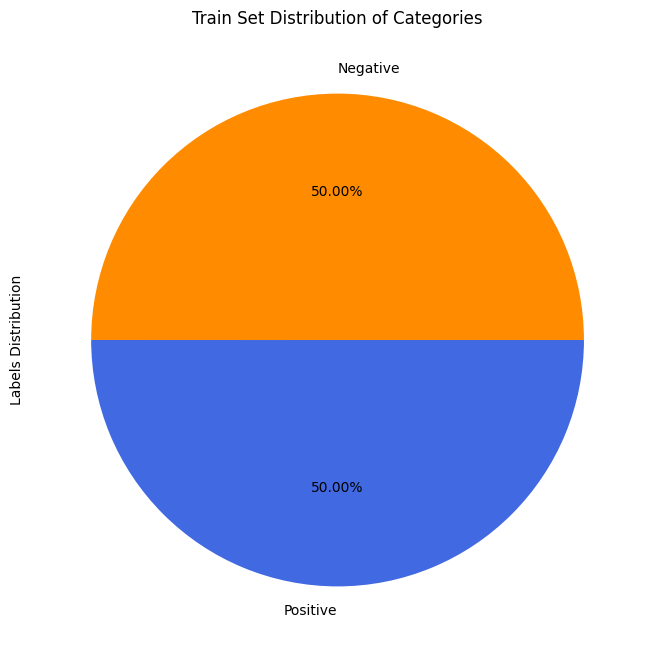

In [19]:
labels_count = df_train['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Train Set Distribution of Categories')

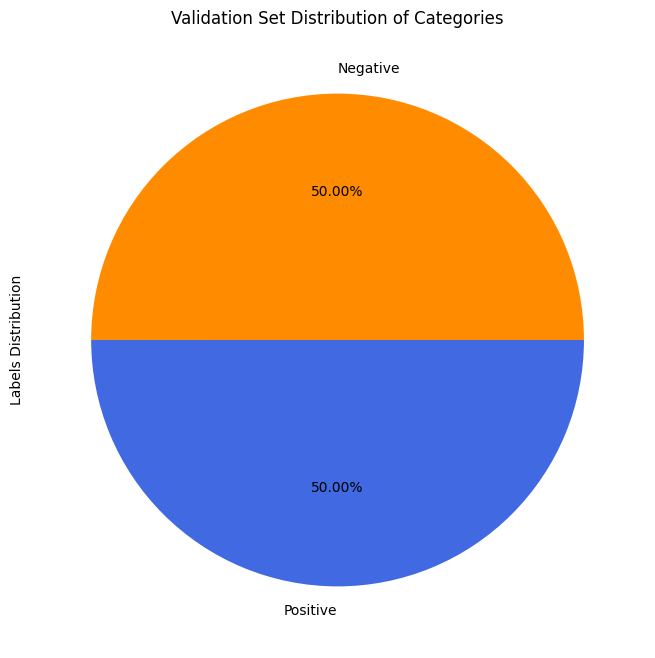

In [20]:
labels_count = df_val['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Validation Set Distribution of Categories')

### Creating a wordcloud using the tweet texts on train set before preprocessing

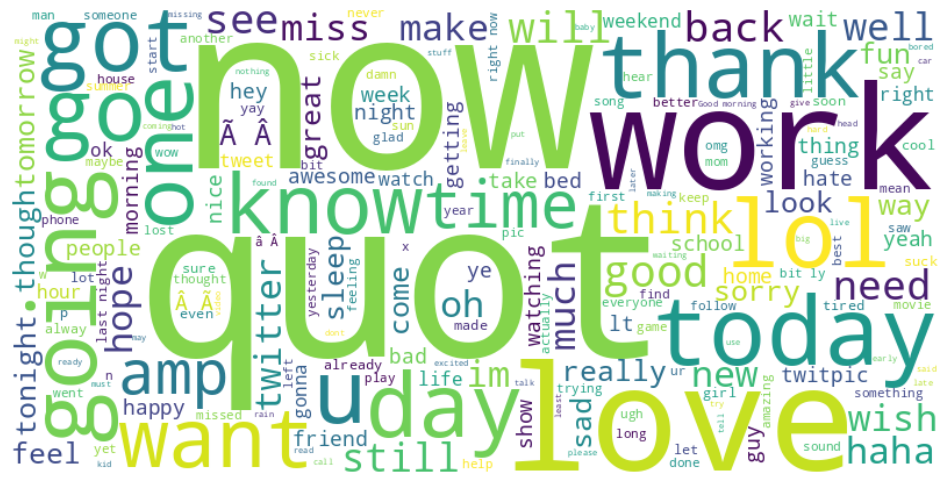

In [21]:
create_wordcloud(df_train['Text'])

### Creating a wordcloud by using only the positive tweets before preprocessing

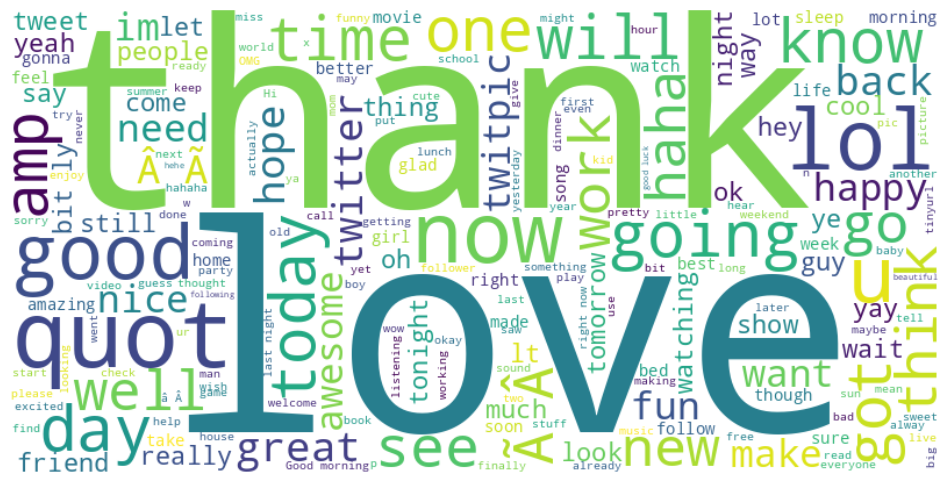

In [22]:
create_wordcloud(df_train[df_train['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets before preprocessing

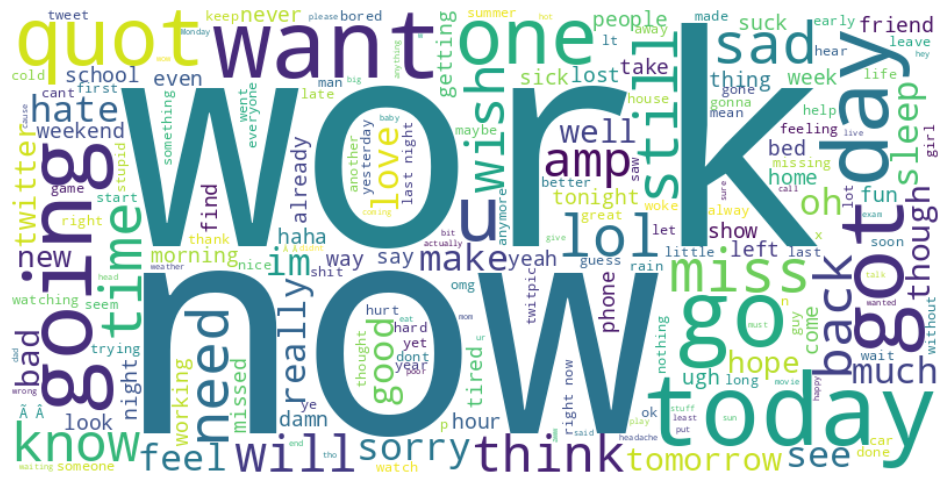

In [23]:
create_wordcloud(df_train[df_train['Label'] == 0]['Text'])

### Plotting a histogram with tweets length across the dataset

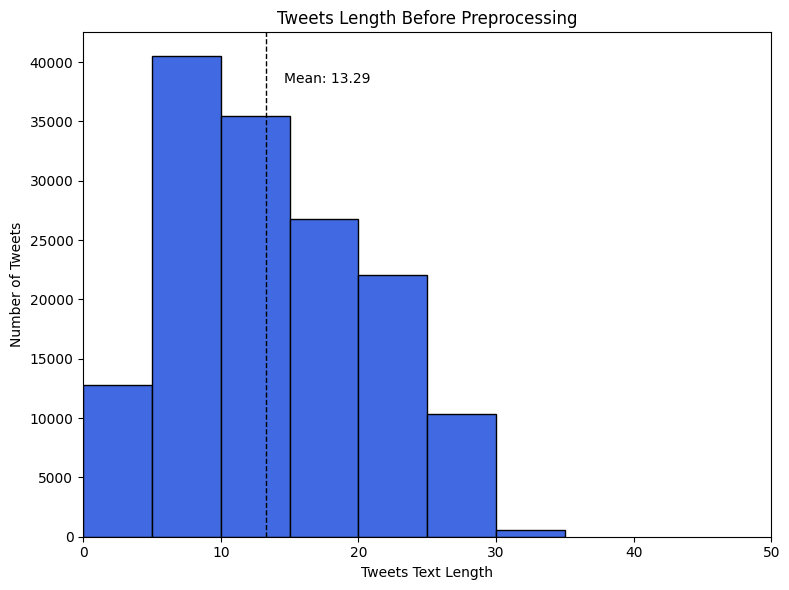

In [24]:
tweets_length = get_tweets_length(df_train)
plot_histogram(tweets_length, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length Before Preprocessing')

### Plotting minimum and maximum length of tweets on train set

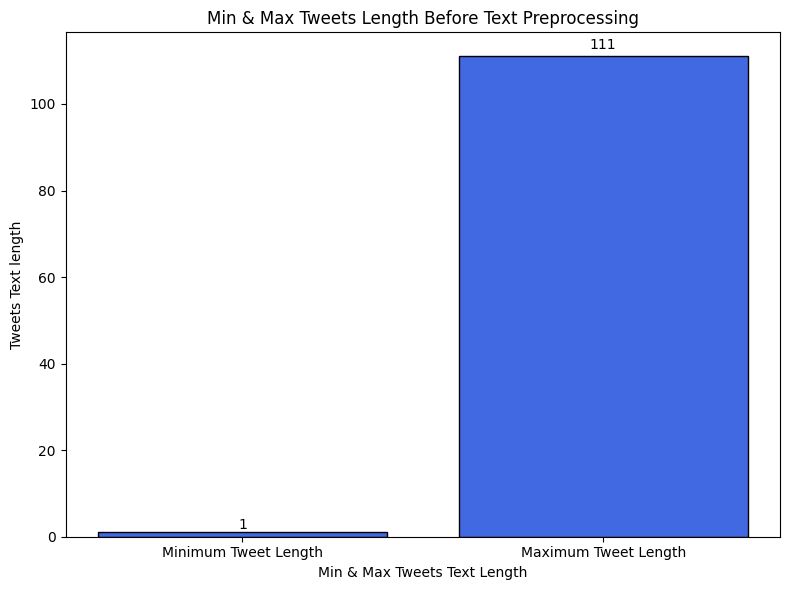

In [25]:
df_min_max = get_min_max_tweets(tweets_length)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Text Length', 'Tweets Text length', 'Min & Max Tweets Length Before Text Preprocessing', False, False, True)

### Plotting the most common words (unigrams) of train dataset

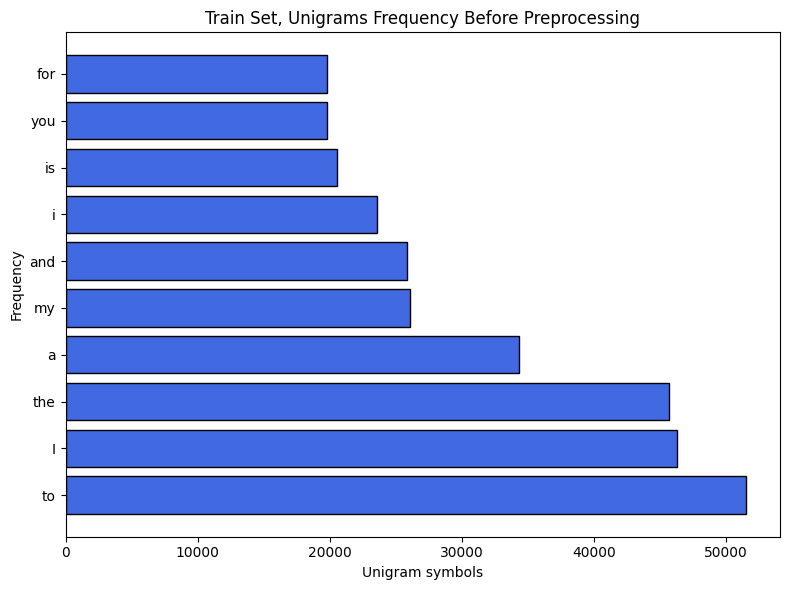

In [26]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train, top=10, n=1)] + ['Unigram symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency Before Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset

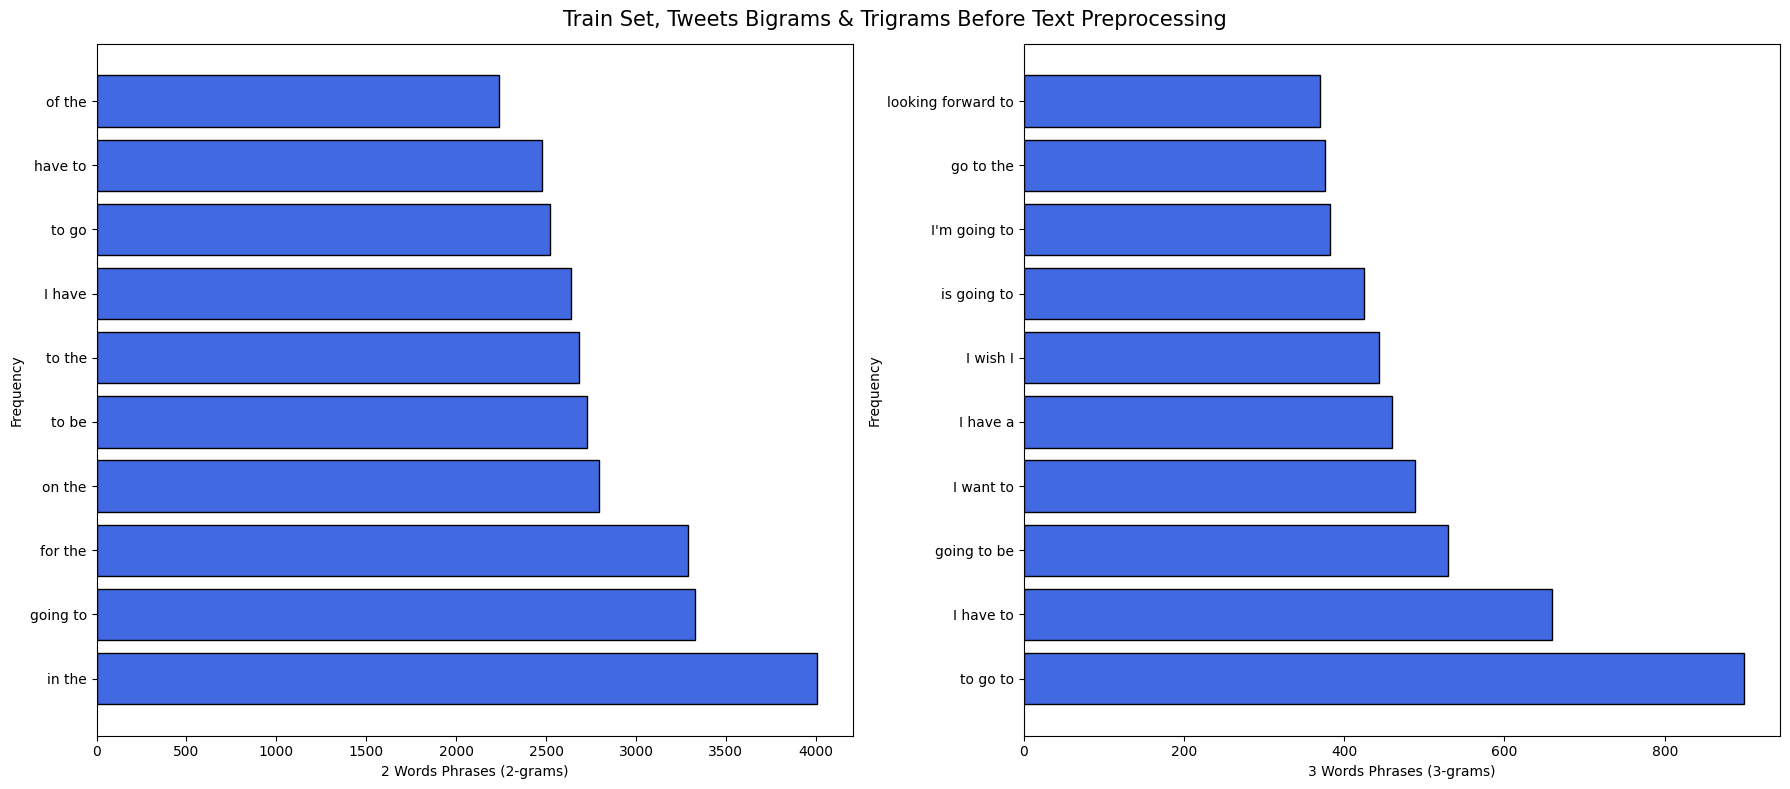

In [27]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams Before Text Preprocessing', bary=True)

### Plotting the number of emails and user mentions found in train dataset (Log Scale)

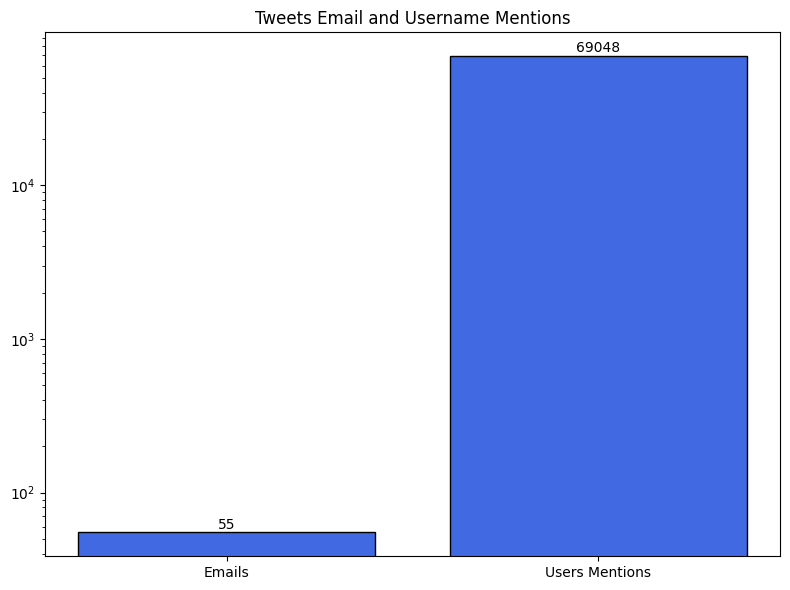

In [28]:
emails_count = df_train.loc[df_train['Text'].str.contains(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{1,}\b'), :].shape[0]

user_mentions_count = df_train.loc[df_train['Text'].str.contains(r'(?<![\w.])@\w+'), :].shape[0]

plot_bar(['Emails', 'Users Mentions'], [emails_count, user_mentions_count], '', '', 'Tweets Email and Username Mentions', False, True, True)

## NLP Text Preprocessing on Tweets

In [18]:
nltk.download('punkt', quiet=True);
nltk.download('stopwords', quiet=True);
nltk.download('wordnet', quiet=True);

### Text Preprocessing is done on two phases:
- Preprocessing with stop words filtering
- Preprocessing with stop words preservation

### The `preprocess_text` function applies the following preprocessing steps:
- **Lowercasing**: Converts all characters to lowercase.
- **Expanding Contractions**: Expanding combinations of words that are shortened.
- **Removing Punctuation Except '@' for Emails and User Mentions**: Eliminating the punctuation of tweets.
- **Anonymizing Mentions**: Username mentions in tweets are converted to '@user'.
- **Anonymizing Email Addresses**: Email addresses are converted to 'XXX@email.com'.
- **Removing URLs**: Removing URLs from text.
- **Removing Digits**: Removing all numeric characters within tweets.
- **Filtering Stop Words**: If 'filter_stopwords' is true then stop words are removed from tweets.
- **Lemmatization**: Coverts the words to their base form.

In [177]:
punctuation = string.punctuation.replace('@', '')
lemmatizer = WordNetLemmatizer()
tokenizer = TweetTokenizer()

def preprocess_text(text, filter_stopwords):
    text = text.lower()
    text = contractions.fix(text)
    
    text = text.translate(str.maketrans('', '', punctuation))
    
    text = re.sub(r'(?<![\w.])@\w+', '@user', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\b', "XXX@email.com", text)
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r'\d+', '', text)
    
    tokens = tokenizer.tokenize(text)
    
    if filter_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

### Removing rows with zero text length (after doing preprocessing) only on train and validation datasets

In [179]:
def filter_non_empty(df):
    return df[df['Text'].str.split().str.len() != 0]

### Function `clean_dataset` does the following steps:
- Creates a copy of the dataframe.
- Removes non-ascii characters from tweets.
- Runs the `preprocess_text` function to further preprocess the tweets (explained above).
- Removes any row with zero text length (on train and validation set only).

In [178]:
def clean_dataset(df, filter_stopwords=False, filter_rows=True):
    df_clean = df.copy()
    df_clean['Text'] = df_clean['Text'].str.encode('ascii', 'ignore').str.decode('ascii')
    df_clean['Text'] = df_clean['Text'].apply(preprocess_text, filter_stopwords=filter_stopwords)
    return filter_non_empty(df_clean) if filter_rows else df_clean

### Running tweets preprocessing on train, validation and test set with filtering stop words activated

In [180]:
df_train_cln = clean_dataset(df_train, filter_stopwords=True)
df_val_cln = clean_dataset(df_val, filter_stopwords=True)
df_test_cln = clean_dataset(df_test, filter_stopwords=True, filter_rows=False)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep   = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

### Displaying the dimenstions of train, validation and test dataset matrices

In [181]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X validation Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y validation Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (148339,)
y train Preprocessed Dimensions: (148339,)
X validation Preprocessed Dimensions: (42385,)
y validation Preprocessed Dimensions: (42385,)
X test Preprocessed Dimensions: (21199,)


### Checking the tweets after running preprocessing

In [21]:
df_train_cln.head()

,ID,Text,Label
0,189385,@user dude bummed leaving,0
1,58036,oh god severed foot foun wheely bin cobham fou...,0
2,190139,end quotdog dialingquot sumtimes dog dialing a...,1
3,99313,@user meeeee toooooo,0
4,157825,hoping could stay home work today look like ma...,0


In [22]:
df_val_cln.head()

,ID,Text,Label
0,187062,@user heyheyhey maybe get could find @user wou...,0
1,168997,@user work work crap missed condescending over...,0
2,194461,want trip boston next month need additl motiva...,1
3,165442,first day start tomorrow,1
4,34853,@user course fish little saigon dessert place ...,1


## Exploratory Data Analysis After Running Text Preprocessing (With Stop Words Filtering)

### Plotting a histogram with tweets length across the training dataset after preprocessing

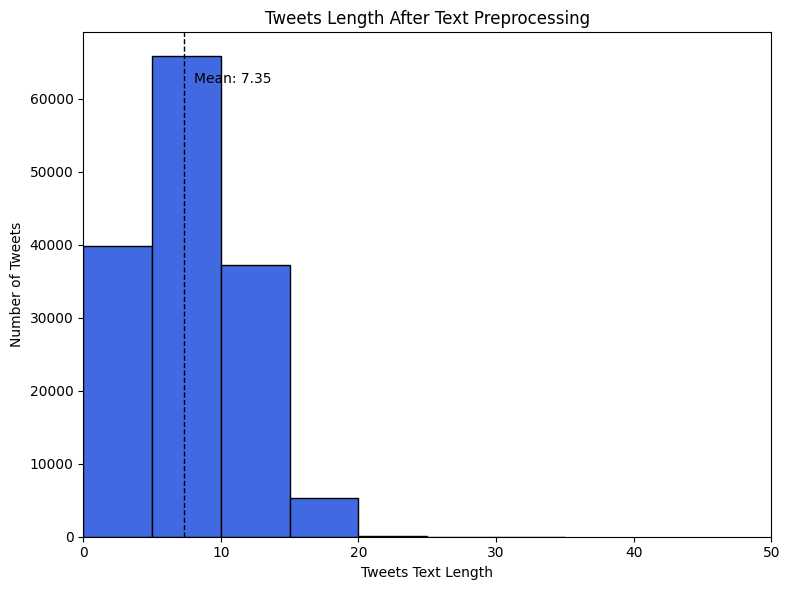

In [37]:
tweets_length_clean = get_tweets_length(df_train_cln)
plot_histogram(tweets_length_clean, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length After Text Preprocessing')

### Plotting minimum and maximum length of tweets after running preprocessing

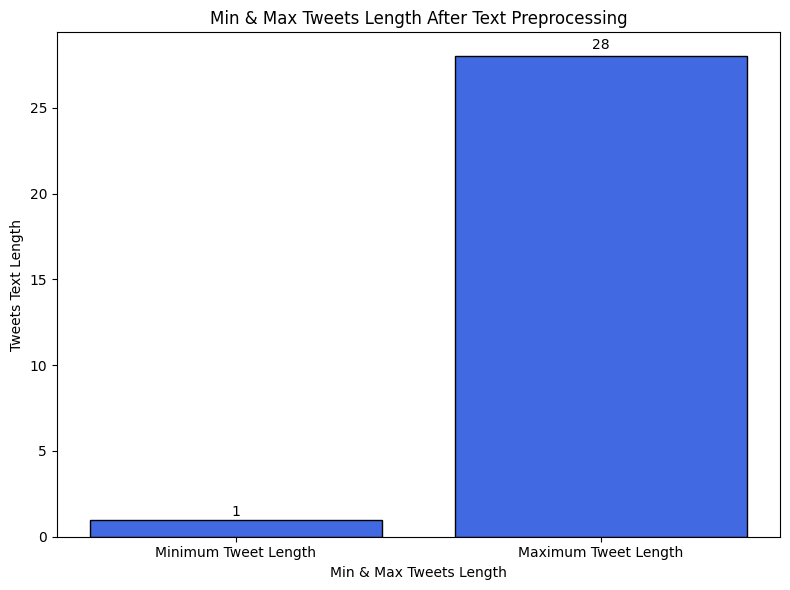

In [38]:
df_min_max = get_min_max_tweets(tweets_length_clean)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Length', 'Tweets Text Length', 'Min & Max Tweets Length After Text Preprocessing', False, False, True)

### Creating a wordcloud using the tweet texts on train set after running preprocessing

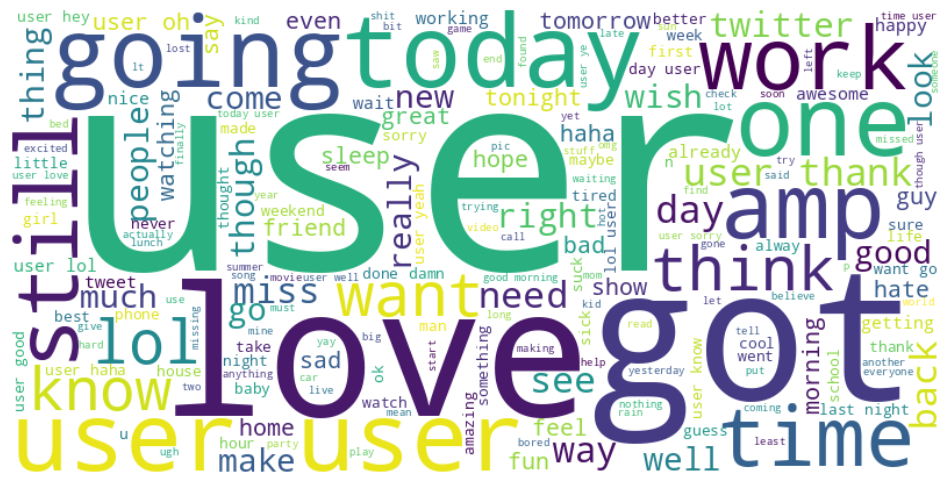

In [39]:
create_wordcloud(df_train_cln['Text'])

### Creating a wordcloud by using only the positive tweets after running preprocessing

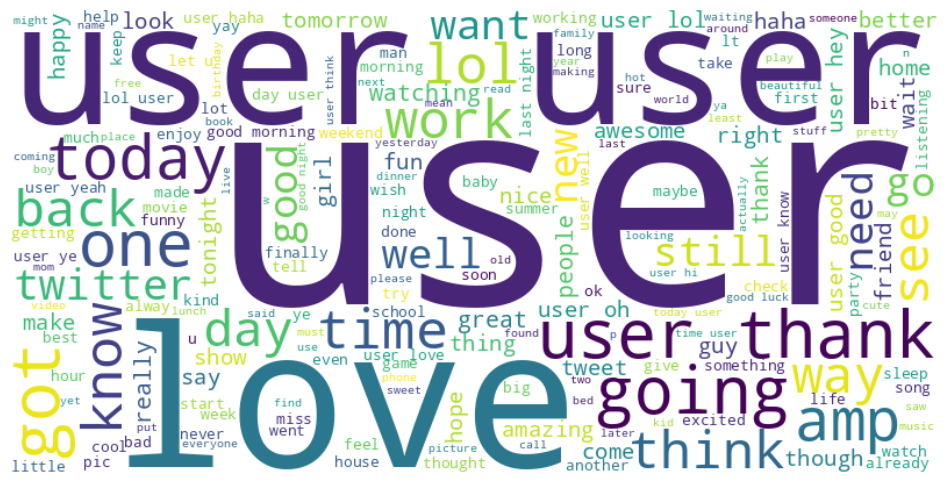

In [40]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets after running preprocessing

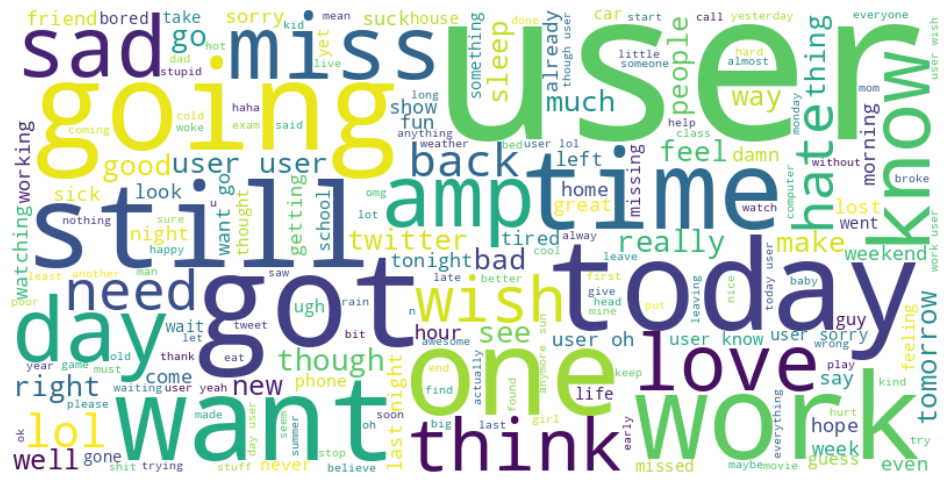

In [41]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 0]['Text'])

### Plotting the most common words (unigrams) of train dataset after running preprocessing

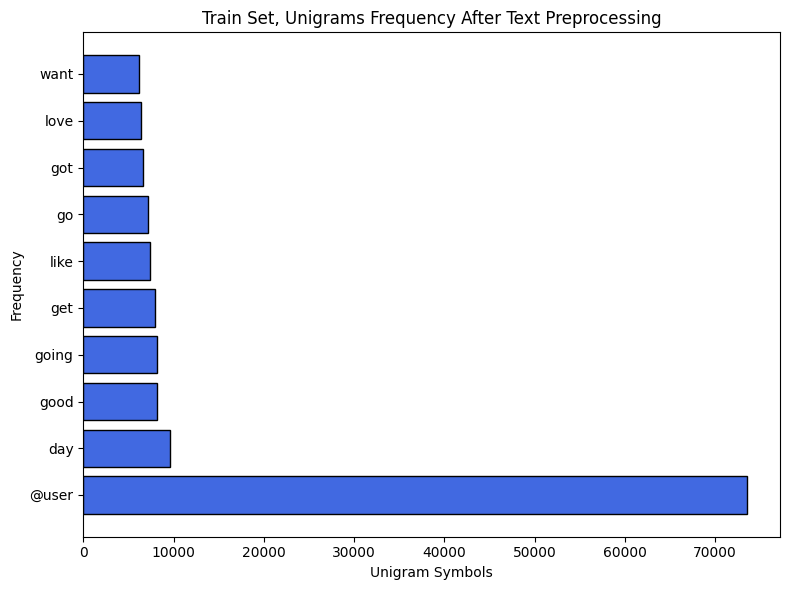

In [42]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency After Text Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset after running preprocessing

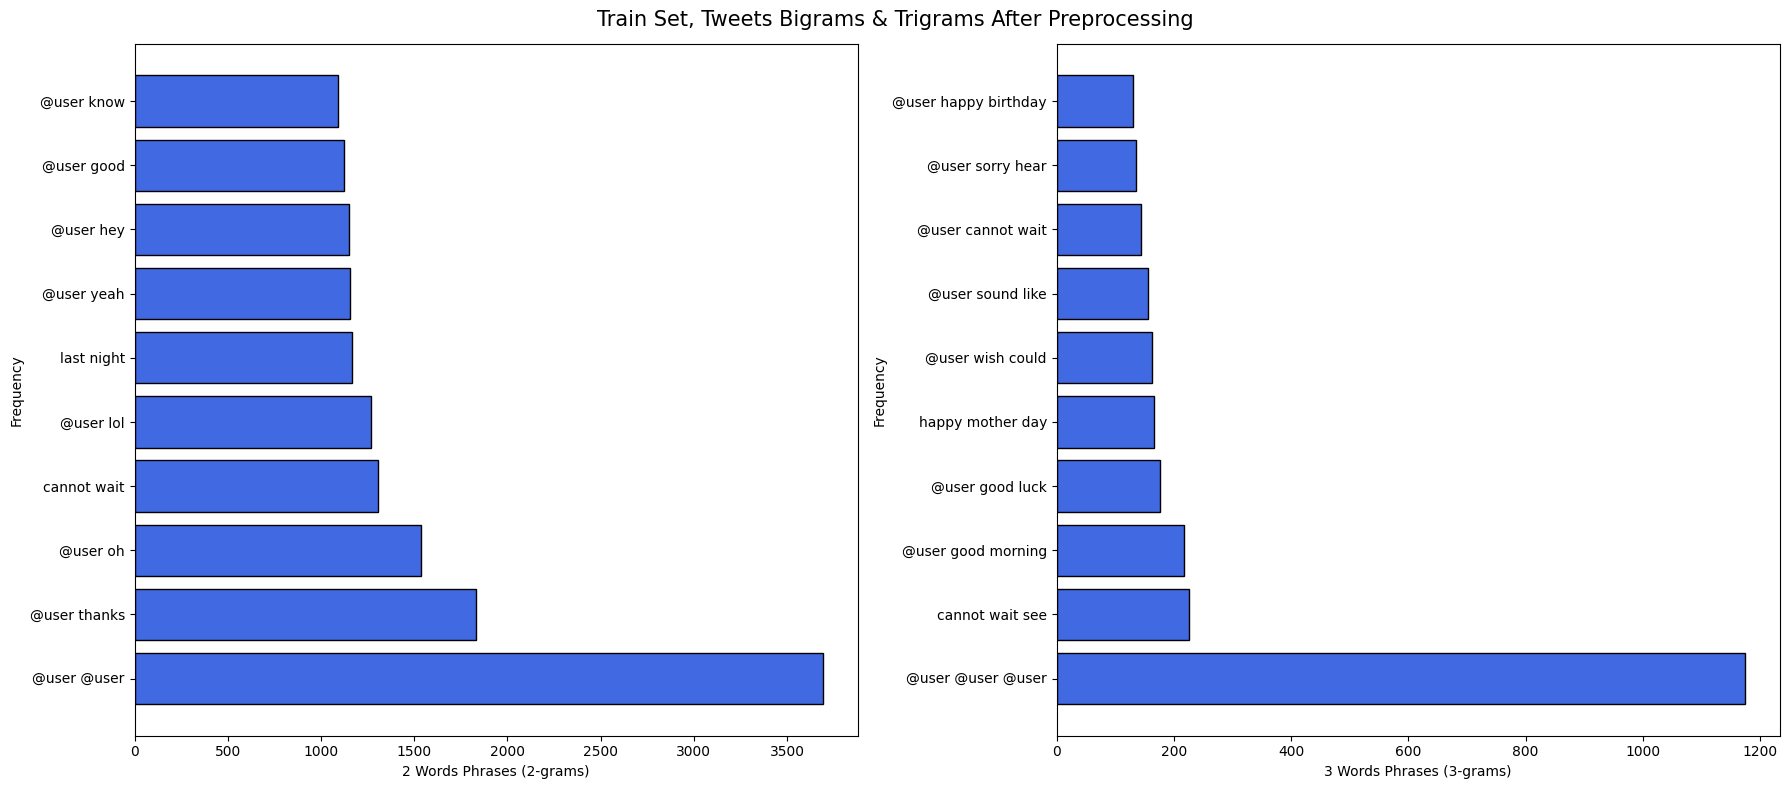

In [43]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

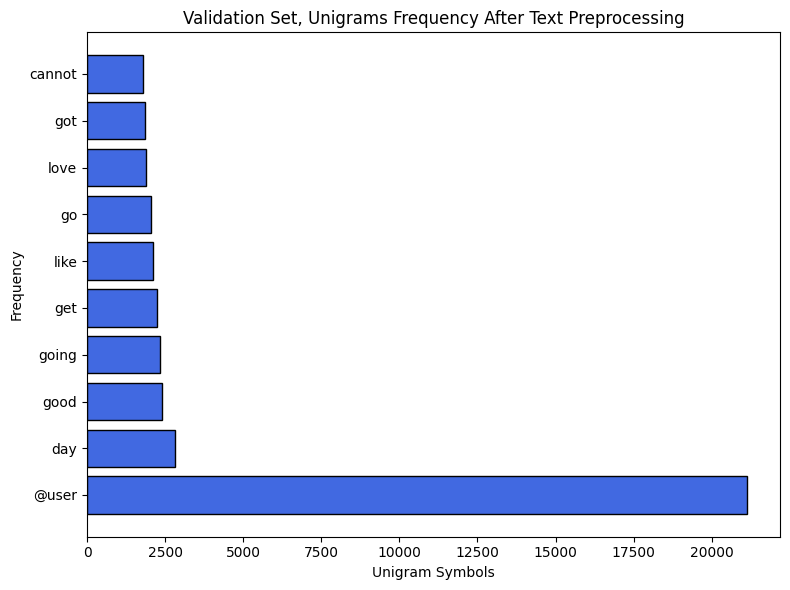

In [44]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Validation Set, Unigrams Frequency After Text Preprocessing', bary=True)

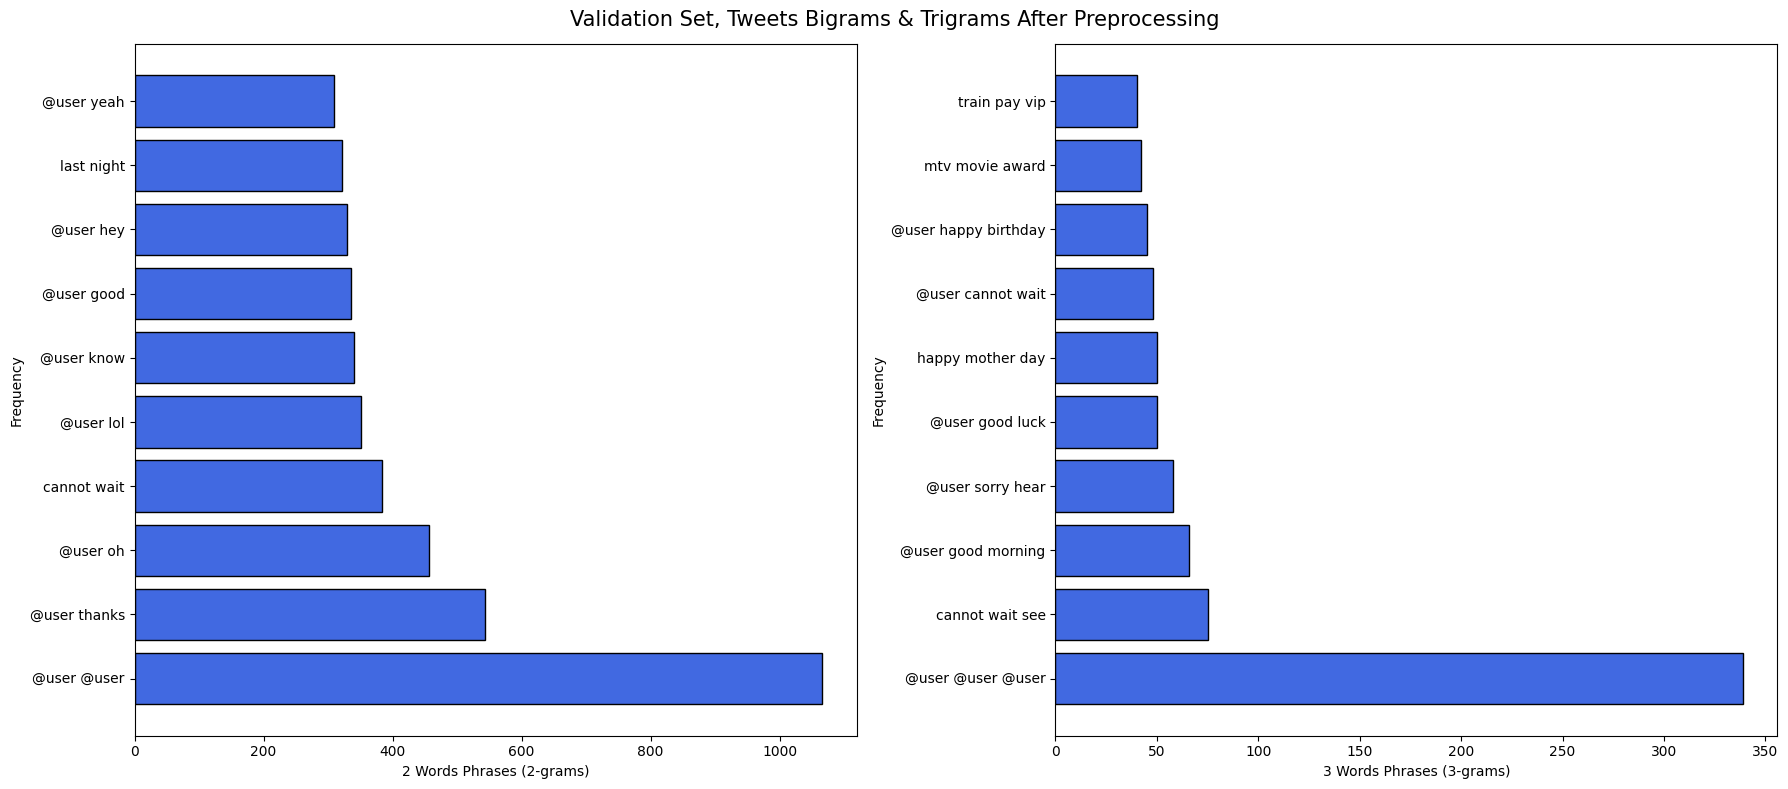

In [45]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Validation Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

## Feature Extraction: Word2Vec using GloVe Hyperparameters Tuning

### Function that calculates **Accuracy**, **Precission**, **Recall** and **F1 scores** and returns a dictionary object

In [244]:
def calc_model_score(y_true, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

### Function that creates multiple subplot bar graphs to display model scores for each hyperparameter configuration 

In [ ]:
def plot_best_scores(results, title="Scores", figsize=(8,6)):
    keys = ['early_accuracy', 'early_precision', 'early_recall', 'early_f1']
    label_mapping = {
        'early_accuracy': 'Accuracy',
        'early_precision': 'Precision',
        'early_recall': 'Recall',
        'early_f1': 'F1'
    }
    colors_list = ['#1C77C3', '#F34213', '#E0CA3C', '#3E2F5B']
    
    scores = [results[key] * 100 for key in keys]
    labels = [label_mapping[key] for key in keys]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(labels, scores, color=colors_list, edgecolor="black")

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.2f}%", 
                ha='center', va='bottom')
    
    ax.set_ylabel("Score (%)")
    ax.set_title(title)
    ax.set_ylim(0, 110)
    
    plt.tight_layout()
    plt.show()

In [251]:
def plot_epochs_scores(history):
    grouped_metrics = {
        'Loss': [
            'Train Loss', 
            'Validation Loss'
        ],
        'Accuracy': [
            'Train Accuracy', 
            'Validation Accuracy'
        ]
    }
    
    single_metrics = [key for key in history.keys() if key not in grouped_metrics['Loss'] and key not in grouped_metrics['Accuracy']]

    fig = plt.figure(figsize=(15, 8))
    outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.4)
    
    gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0], wspace=0.3)
    ax_grouped1 = fig.add_subplot(gs_top[0, 0])
    ax_grouped2 = fig.add_subplot(gs_top[0, 1])
    
    gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer_gs[1], wspace=0.3)
    ax_single1 = fig.add_subplot(gs_bottom[0, 0])
    ax_single2 = fig.add_subplot(gs_bottom[0, 1])
    ax_single3 = fig.add_subplot(gs_bottom[0, 2])
    
    axes_grouped = [ax_grouped1, ax_grouped2]
    for ax, (title, keys) in zip(axes_grouped, grouped_metrics.items()):
        for key in keys:
            ax.plot(history[key], marker='o', label=key)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(title, fontsize=10)
        ax.grid(True)
        ax.legend(fontsize=8)
    
    axes_single = [ax_single1, ax_single2, ax_single3]
    for ax, metric in zip(axes_single, single_metrics):
        ax.plot(history[metric], marker='o')
        ax.set_title(metric, fontsize=12)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(metric, fontsize=10)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

### Function that calculates the ROC curve

In [184]:
def calc_roc_curve(y, y_pred):
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

### Function that plots the ROC curve

In [185]:
def plot_roc_curve(fpr, tpr, roc_auc, estimator_name):
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=estimator_name)
    display.plot()
    plt.show()

### Function that calculates the confusion matrix, given the classification labels

In [186]:
def calc_confusion_matrix(y, y_pred, clf):
    return confusion_matrix(y, y_pred, labels=clf.classes_)

### Function that plots the confusion matrix

In [187]:
def plot_confusion_matrix(cm, clf):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot()
    plt.show()

#### The acronyms used on preprocessing experimentations are the following: 

#### - **PRFS**: Preprocessing & Filtering Stopwords
#### - **PRPS**: Preprocessing & Preserving Stopwords

In [29]:
embeddings_dim = 300

glove_input_file = 'glove.6B.300d.txt'
word2vec_output_file = 'glv_with_w2v_format.txt'

glove2word2vec(glove_input_file, word2vec_output_file)
glove = KeyedVectors.load_word2vec_format(word2vec_output_file)

In [197]:
def tokens_to_embeddings(df_tokens, glove_model, embeddings_dim):
    embeddings = []
    for tokens in df_tokens:
        vecs = []
        for token in tokens:
            if token in glove_model:
                vecs.append(glove_model[token])

        if len(vecs) == 0:
            embeddings.append(torch.zeros(1, embeddings_dim))
        else:
            embeddings.append(torch.tensor(np.array(vecs), dtype=torch.float32))
            
    return embeddings

In [195]:
def get_mean_embeddings(X, glove, embeddings_dim):
    tknzr = TweetTokenizer()
    toks = X.apply(lambda x: tknzr.tokenize(x))
    X = tokens_to_embeddings(toks, glove, embeddings_dim)
    X = torch.stack([torch.mean(sentence, dim=0) for sentence in X])
    X_tensor = X.view(X.size(0), -1)
    return X_tensor


In [190]:
class NeuralNet(nn.Module):
    def __init__(self, D_in, hidden_sizes, D_out=1, activations=None, dropout=0.0, enable_batch_norm=False):
        super(NeuralNet, self).__init__()

        if activations is None:
            activations = [nn.ReLU()] * len(hidden_sizes)

        layers = []
        in_dim = D_in

        for activation_func, hidden_layer in zip(activations, hidden_sizes):
            layers.append(nn.Linear(in_dim, hidden_layer))
            
            if enable_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_layer))
            
            layers.append(activation_func())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
                
            in_dim = hidden_layer

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(in_dim, D_out)
        
    def forward(self, x):
        x = self.hidden_layers(x)
        return self.output_layer(x)


In [191]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    return epoch_loss

In [192]:
def evaluate_model(model, dataloader, loss_fn=None, device='cpu', threshold=0.5):
    model.eval()
    y_pred_list = []
    y_true_list = []
    total_loss = 0.0
    
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            
            if loss_fn:
                total_loss += loss_fn(y_pred, y_batch).item()
            
            y_pred = torch.sigmoid(y_pred)
            y_pred = (y_pred > threshold).float()
            
            y_pred_list.append(y_pred.cpu().numpy())
            y_true_list.append(y_batch.cpu().numpy())
    
    y_pred_list = np.concatenate(y_pred_list)
    y_true_list = np.concatenate(y_true_list)
    
    avg_loss = total_loss / len(dataloader) if loss_fn else None
    
    return {**calc_model_score(y_true_list, y_pred_list), 'loss': avg_loss}


In [ ]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, n_epochs, device='cpu', early=False, print_res=1):

    results = {
        'Train Loss': [], 
        'Validation Loss': [],
        'Train Accuracy': [], 
        'Validation Accuracy': [],
        'Validation Precision': [],
        'Validation Recall': [],
        'Validation F1 Score': []
    }
    
    no_loss_improve = 0
    best_val_loss = float('inf')
    best_state = None
    best_epoch = 1

    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device=device)
        
        train_metrics = evaluate_model(model, train_loader, loss_fn=loss_fn, device=device)
        val_metrics = evaluate_model(model, val_loader, loss_fn=loss_fn, device=device) 

        results['Train Loss'].append(train_loss)
        results['Validation Loss'].append(val_metrics['loss'])
        
        results['Train Accuracy'].append(train_metrics['Accuracy'])
        results['Validation Accuracy'].append(val_metrics['Accuracy'])
        results['Validation Precision'].append(val_metrics['Precision'])
        results['Validation Recall'].append(val_metrics['Recall'])
        results['Validation F1 Score'].append(val_metrics['F1 Score'])

        if epoch % print_res == 0:
            print(f"Epoch {epoch}/{n_epochs} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
                f"Train Acc: {train_metrics['Accuracy']:.4f} | "
                f"Val Acc: {val_metrics['Accuracy']:.4f} | "
                f"Val Precision: {val_metrics['Precision']:.4f} | "
                f"Val Recall: {val_metrics['Recall']:.4f} | "
                f"Val F1: {val_metrics['F1 Score']:.4f}"
            )
        
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            no_loss_improve = 0
            best_epoch = epoch
            results['early_accuracy'] = val_metrics['Accuracy']
            results['early_precision'] = val_metrics['Precision']
            results['early_recall'] = val_metrics['Recall']
            results['early_f1'] = val_metrics['F1 Score']
            best_state = model.state_dict()
        else:
            no_loss_improve += 1

        if early and no_loss_improve >= 3:
            print(f"Early stopping triggered after {epoch} epochs.")
            print(f"Best model found at epoch {best_epoch} with validation loss {best_val_loss:.4f}")
            model.load_state_dict(best_state)
            break
    
    return results


In [198]:
X_train_tensor = get_mean_embeddings(X_train_prep, glove, embeddings_dim)
X_val_tensor = get_mean_embeddings(X_val_prep, glove, embeddings_dim)
X_test_tensor = get_mean_embeddings(X_test_prep, glove, embeddings_dim)

X_train_tensor

tensor([[ 0.0057, -0.2506,  0.0084,  ...,  0.1038,  0.0379,  0.3429],
        [-0.0983, -0.0559, -0.2372,  ...,  0.0240, -0.1322,  0.0114],
        [-0.1033,  0.1154,  0.0846,  ...,  0.0476,  0.1009,  0.0927],
        ...,
        [-0.1866, -0.0419, -0.0284,  ..., -0.1621, -0.0942,  0.2721],
        [ 0.1037, -0.1013,  0.0615,  ...,  0.0225, -0.1120,  0.1771],
        [-0.4208,  0.1395,  0.0029,  ..., -0.0959, -0.2120, -0.1991]])

In [199]:
y_train_tensor = torch.tensor(y_train_prep.values).float().unsqueeze(1)
y_val_tensor = torch.tensor(y_val_prep.values).float().unsqueeze(1)

In [200]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [201]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Epoch 5/50 | Train Loss: 0.4956 | Val Loss: 0.5258 | Train Acc: 0.7682 | Val Acc: 0.7369 | Val Precision: 0.7472 | Val Recall: 0.7161 | Val F1: 0.7313
Epoch 10/50 | Train Loss: 0.4528 | Val Loss: 0.5479 | Train Acc: 0.7939 | Val Acc: 0.7308 | Val Precision: 0.7229 | Val Recall: 0.7486 | Val F1: 0.7355
Epoch 15/50 | Train Loss: 0.4182 | Val Loss: 0.5785 | Train Acc: 0.8140 | Val Acc: 0.7239 | Val Precision: 0.7055 | Val Recall: 0.7687 | Val F1: 0.7357
Epoch 20/50 | Train Loss: 0.3892 | Val Loss: 0.6159 | Train Acc: 0.8346 | Val Acc: 0.7204 | Val Precision: 0.7181 | Val Recall: 0.7255 | Val F1: 0.7218
Epoch 25/50 | Train Loss: 0.3660 | Val Loss: 0.6590 | Train Acc: 0.8450 | Val Acc: 0.7188 | Val Precision: 0.7160 | Val Recall: 0.7252 | Val F1: 0.7206
Epoch 30/50 | Train Loss: 0.3455 | Val Loss: 0.7180 | Train Acc: 0.8553 | Val Acc: 0.7150 | Val Precision: 0.7155 | Val Recall: 0.7139 | Val F1: 0.7147
Epoch 35/50 | Train Loss: 0.3284 | Val Loss: 0.7548 | Train Acc: 0.8654 | Val Acc: 0.7109

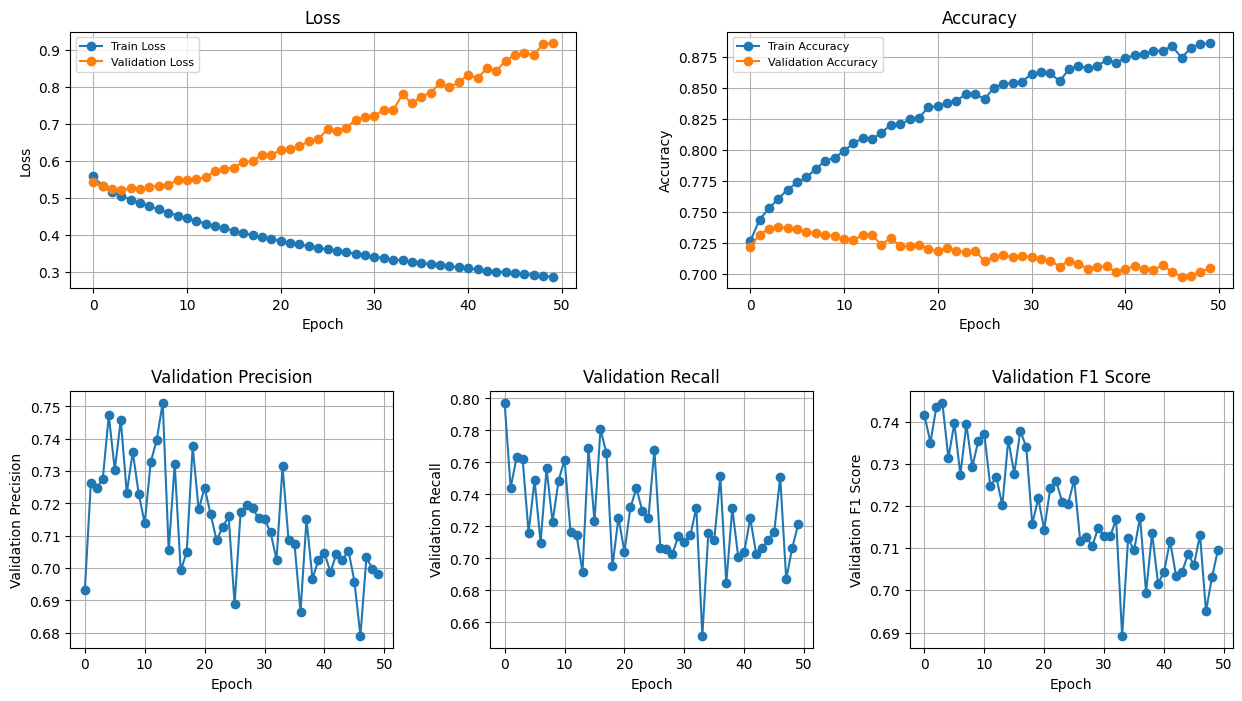

In [217]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[128, 64], D_out=1, activations=[nn.ReLU, nn.ReLU]).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader, 
    val_loader, 
    loss_fn, 
    optimizer, 
    n_epochs=50,
    device=device,
    print_res=5
)

plot_epochs_scores(results)

### Running a basic model with filtering stopwords

### Preprocessing without filtering stop words

In [218]:
df_train_cln = clean_dataset(df_train, filter_stopwords=False)
df_val_cln = clean_dataset(df_val, filter_stopwords=False)
df_test_cln = clean_dataset(df_test, filter_stopwords=False, filter_rows=False)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

In [219]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X_val Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y val Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (148388,)
y train Preprocessed Dimensions: (148388,)
X_val Preprocessed Dimensions: (42396,)
y val Preprocessed Dimensions: (42396,)
X test Preprocessed Dimensions: (21199,)


In [220]:
X_train_tensor = get_mean_embeddings(X_train_prep, glove, embeddings_dim)
X_val_tensor = get_mean_embeddings(X_val_prep, glove, embeddings_dim)
X_test_tensor = get_mean_embeddings(X_test_prep, glove, embeddings_dim)

X_train_tensor

tensor([[-0.0584, -0.0302,  0.0555,  ..., -0.1571,  0.0686,  0.3089],
        [-0.1883,  0.0092, -0.1950,  ..., -0.1061, -0.1549,  0.1139],
        [-0.1564,  0.1401, -0.0022,  ..., -0.0598, -0.0095,  0.1512],
        ...,
        [-0.1277, -0.0112, -0.0793,  ..., -0.1427, -0.0071,  0.2991],
        [ 0.0628, -0.0156,  0.0293,  ..., -0.0196, -0.1233,  0.1383],
        [-0.2649,  0.1445, -0.0896,  ..., -0.1938, -0.1652, -0.0093]])

In [221]:
y_train_tensor = torch.tensor(y_train_prep.values).float().unsqueeze(1)
y_val_tensor = torch.tensor(y_val_prep.values).float().unsqueeze(1)

In [222]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

Epoch 5/50 | Train Loss: 0.4844 | Val Loss: 0.5082 | Train Acc: 0.7634 | Val Acc: 0.7464 | Val Precision: 0.7137 | Val Recall: 0.8227 | Val F1: 0.7644
Epoch 10/50 | Train Loss: 0.4524 | Val Loss: 0.5012 | Train Acc: 0.7906 | Val Acc: 0.7600 | Val Precision: 0.7782 | Val Recall: 0.7271 | Val F1: 0.7518
Epoch 15/50 | Train Loss: 0.4267 | Val Loss: 0.5180 | Train Acc: 0.8055 | Val Acc: 0.7549 | Val Precision: 0.7683 | Val Recall: 0.7298 | Val F1: 0.7486
Epoch 20/50 | Train Loss: 0.4050 | Val Loss: 0.5508 | Train Acc: 0.8122 | Val Acc: 0.7470 | Val Precision: 0.7775 | Val Recall: 0.6922 | Val F1: 0.7324
Epoch 25/50 | Train Loss: 0.3855 | Val Loss: 0.5727 | Train Acc: 0.8290 | Val Acc: 0.7475 | Val Precision: 0.7589 | Val Recall: 0.7256 | Val F1: 0.7419
Epoch 30/50 | Train Loss: 0.3699 | Val Loss: 0.6158 | Train Acc: 0.8347 | Val Acc: 0.7427 | Val Precision: 0.7683 | Val Recall: 0.6949 | Val F1: 0.7298
Epoch 35/50 | Train Loss: 0.3547 | Val Loss: 0.6473 | Train Acc: 0.8440 | Val Acc: 0.7433

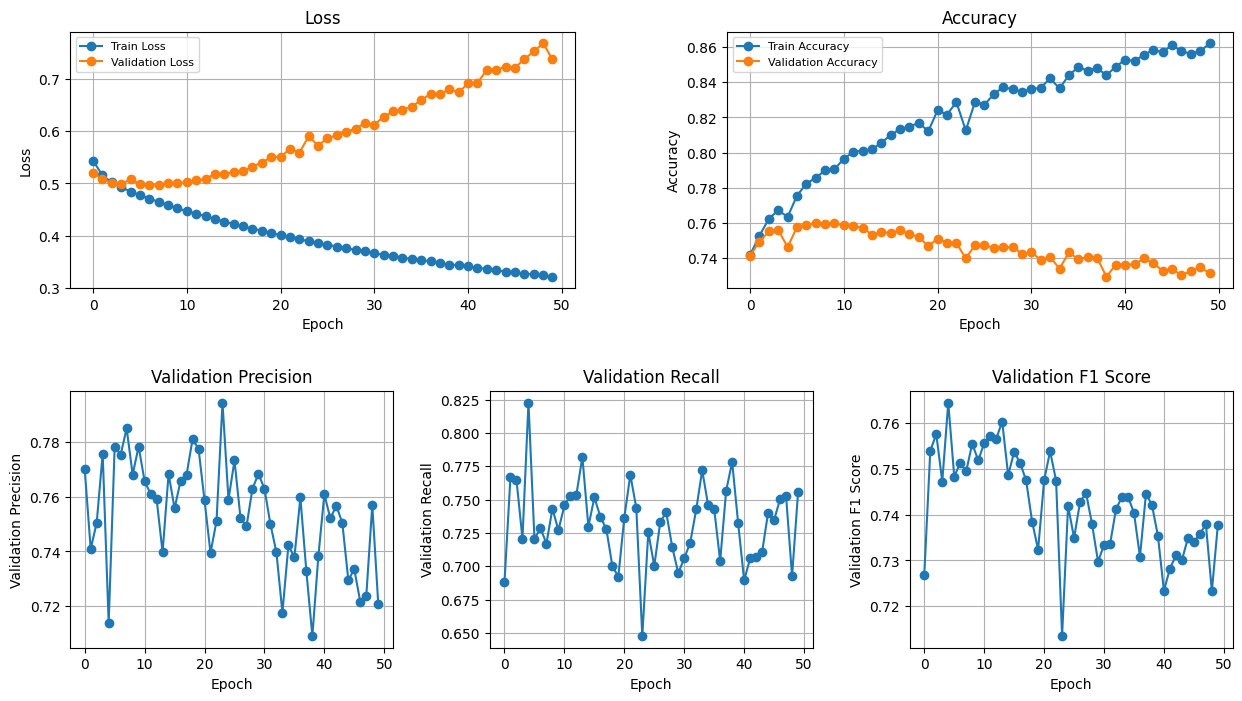

In [ ]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[128, 64], D_out=1, activations=[nn.ReLU, nn.ReLU]).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader,
    val_loader, 
    loss_fn, 
    optimizer, 
    n_epochs=50,
    device=device,
    print_res=5
)

plot_epochs_scores(results)

### Addressing overfitting issue

Epoch 10/50 | Train Loss: 0.5075 | Val Loss: 0.5005 | Train Acc: 0.7673 | Val Acc: 0.7579 | Val Precision: 0.7538 | Val Recall: 0.7658 | Val F1: 0.7598
Epoch 20/50 | Train Loss: 0.4923 | Val Loss: 0.4959 | Train Acc: 0.7760 | Val Acc: 0.7585 | Val Precision: 0.7446 | Val Recall: 0.7868 | Val F1: 0.7651
Epoch 30/50 | Train Loss: 0.4845 | Val Loss: 0.4943 | Train Acc: 0.7822 | Val Acc: 0.7614 | Val Precision: 0.7927 | Val Recall: 0.7080 | Val F1: 0.7480
Epoch 40/50 | Train Loss: 0.4784 | Val Loss: 0.4947 | Train Acc: 0.7850 | Val Acc: 0.7580 | Val Precision: 0.7372 | Val Recall: 0.8019 | Val F1: 0.7682
Epoch 50/50 | Train Loss: 0.4734 | Val Loss: 0.4904 | Train Acc: 0.7939 | Val Acc: 0.7633 | Val Precision: 0.7713 | Val Recall: 0.7484 | Val F1: 0.7597


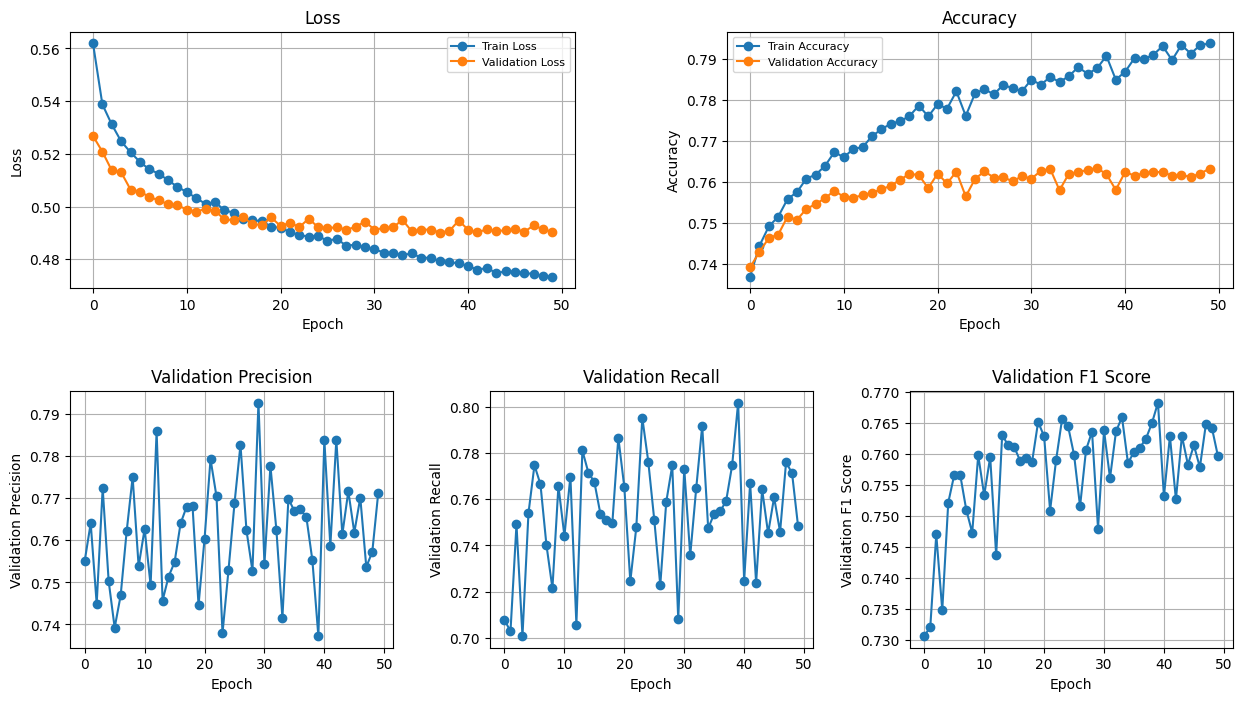

In [253]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[128, 64], dropout=0.5, D_out=1, activations=[nn.ReLU, nn.ReLU]).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader, 
    val_loader, 
    loss_fn, 
    optimizer, 
    n_epochs=50,
    device=device,
    print_res=10
)

plot_epochs_scores(results)

### Testing multiple hidden layers configurations using early stopping

In [279]:
hidden_sizes_list = [
    [256, 128, 64],
    [512, 256, 128],
    [256, 128, 64, 32],
    [512, 256, 128, 64],
]

Epoch 1/50 | Train Loss: 0.5633 | Val Loss: 0.5252 | Train Acc: 0.7381 | Val Acc: 0.7384 | Val Precision: 0.7357 | Val Recall: 0.7441 | Val F1: 0.7399
Epoch 2/50 | Train Loss: 0.5384 | Val Loss: 0.5192 | Train Acc: 0.7454 | Val Acc: 0.7445 | Val Precision: 0.7434 | Val Recall: 0.7466 | Val F1: 0.7450
Epoch 3/50 | Train Loss: 0.5284 | Val Loss: 0.5131 | Train Acc: 0.7498 | Val Acc: 0.7454 | Val Precision: 0.7770 | Val Recall: 0.6883 | Val F1: 0.7300
Epoch 4/50 | Train Loss: 0.5229 | Val Loss: 0.5098 | Train Acc: 0.7576 | Val Acc: 0.7526 | Val Precision: 0.7661 | Val Recall: 0.7273 | Val F1: 0.7462
Epoch 5/50 | Train Loss: 0.5178 | Val Loss: 0.5074 | Train Acc: 0.7537 | Val Acc: 0.7487 | Val Precision: 0.7910 | Val Recall: 0.6760 | Val F1: 0.7290
Epoch 6/50 | Train Loss: 0.5136 | Val Loss: 0.5052 | Train Acc: 0.7612 | Val Acc: 0.7507 | Val Precision: 0.7464 | Val Recall: 0.7596 | Val F1: 0.7529
Epoch 7/50 | Train Loss: 0.5093 | Val Loss: 0.5046 | Train Acc: 0.7645 | Val Acc: 0.7528 | Val

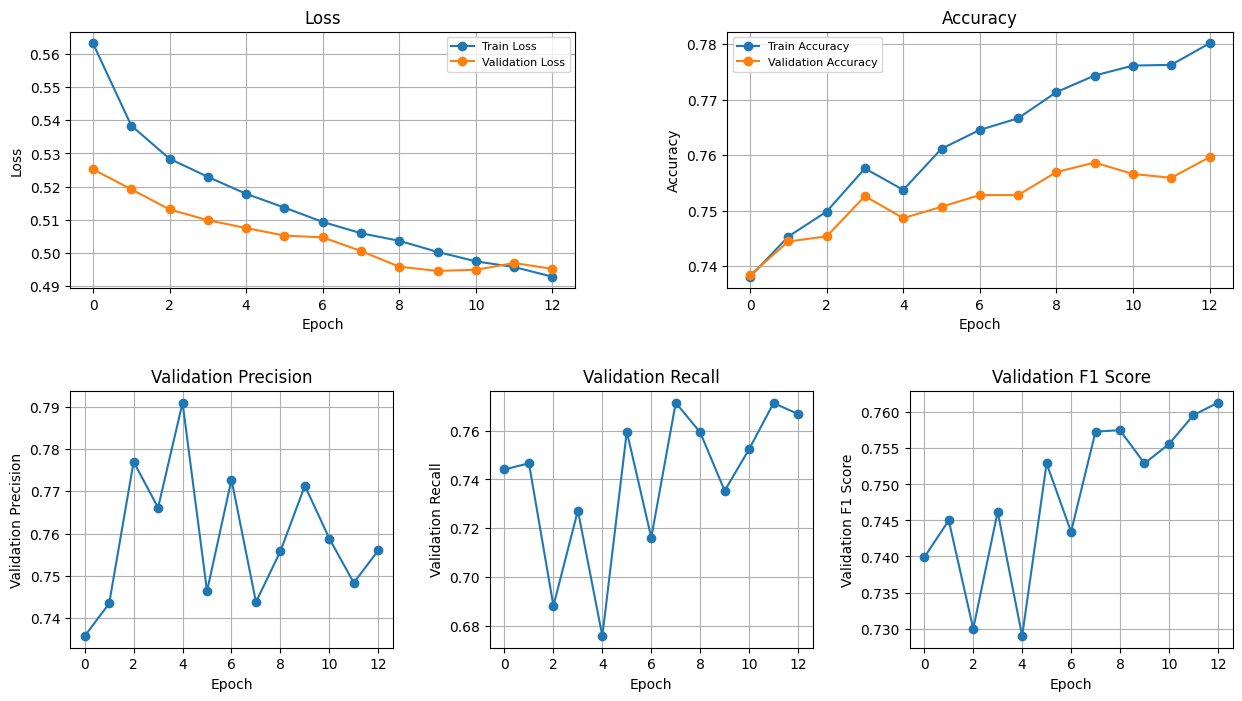

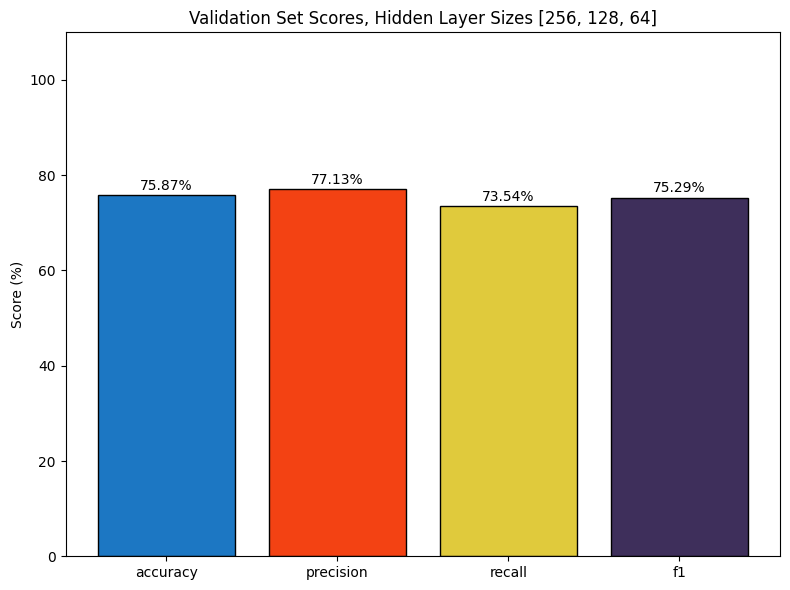

Epoch 1/50 | Train Loss: 0.5573 | Val Loss: 0.5249 | Train Acc: 0.7383 | Val Acc: 0.7382 | Val Precision: 0.7623 | Val Recall: 0.6924 | Val F1: 0.7257
Epoch 2/50 | Train Loss: 0.5329 | Val Loss: 0.5168 | Train Acc: 0.7448 | Val Acc: 0.7426 | Val Precision: 0.7321 | Val Recall: 0.7654 | Val F1: 0.7484
Epoch 3/50 | Train Loss: 0.5230 | Val Loss: 0.5074 | Train Acc: 0.7551 | Val Acc: 0.7507 | Val Precision: 0.7621 | Val Recall: 0.7290 | Val F1: 0.7452
Epoch 4/50 | Train Loss: 0.5158 | Val Loss: 0.5015 | Train Acc: 0.7596 | Val Acc: 0.7525 | Val Precision: 0.7480 | Val Recall: 0.7615 | Val F1: 0.7547
Epoch 5/50 | Train Loss: 0.5102 | Val Loss: 0.5004 | Train Acc: 0.7639 | Val Acc: 0.7552 | Val Precision: 0.7479 | Val Recall: 0.7698 | Val F1: 0.7587
Epoch 6/50 | Train Loss: 0.5066 | Val Loss: 0.5009 | Train Acc: 0.7649 | Val Acc: 0.7571 | Val Precision: 0.7907 | Val Recall: 0.6992 | Val F1: 0.7422
Epoch 7/50 | Train Loss: 0.5013 | Val Loss: 0.5016 | Train Acc: 0.7670 | Val Acc: 0.7525 | Val

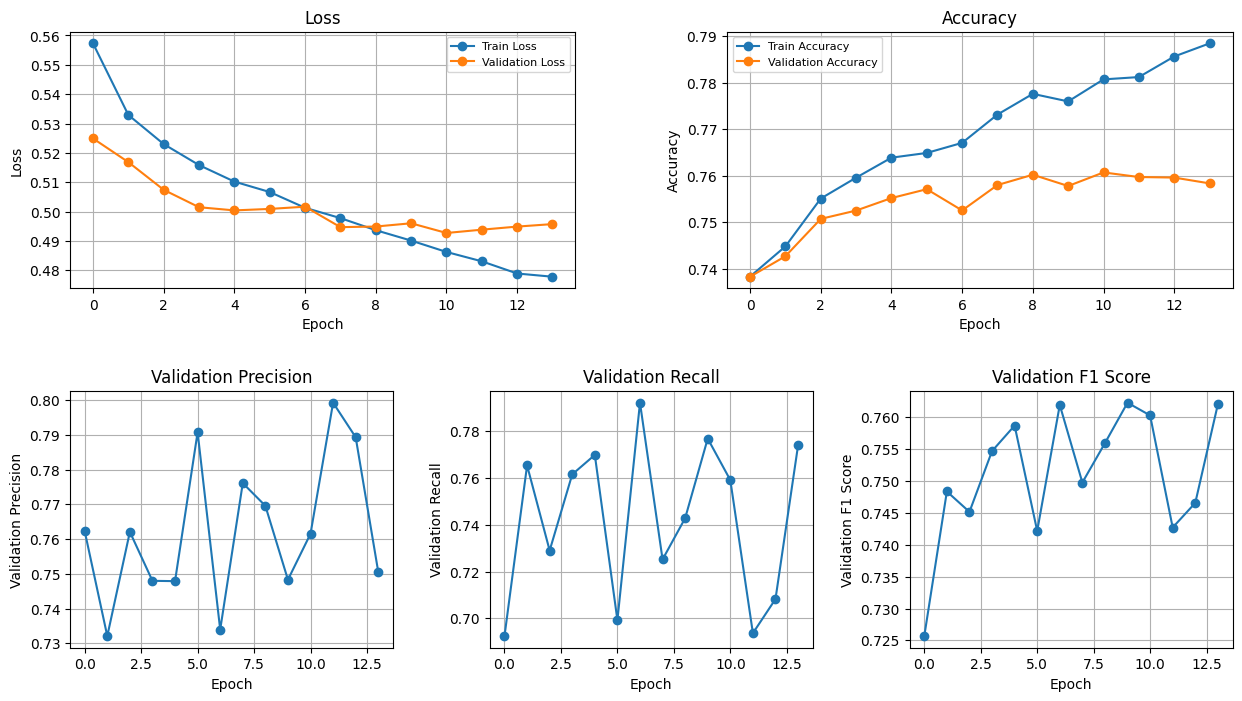

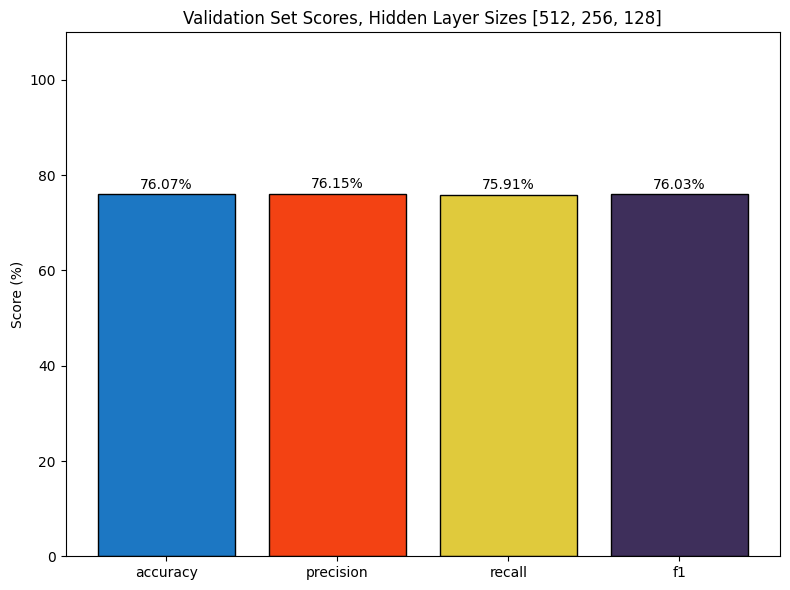

Epoch 1/50 | Train Loss: 0.5726 | Val Loss: 0.5280 | Train Acc: 0.7355 | Val Acc: 0.7345 | Val Precision: 0.7217 | Val Recall: 0.7633 | Val F1: 0.7420
Epoch 2/50 | Train Loss: 0.5447 | Val Loss: 0.5207 | Train Acc: 0.7436 | Val Acc: 0.7422 | Val Precision: 0.7673 | Val Recall: 0.6954 | Val F1: 0.7296
Epoch 3/50 | Train Loss: 0.5365 | Val Loss: 0.5113 | Train Acc: 0.7518 | Val Acc: 0.7483 | Val Precision: 0.7558 | Val Recall: 0.7337 | Val F1: 0.7446
Epoch 4/50 | Train Loss: 0.5308 | Val Loss: 0.5098 | Train Acc: 0.7559 | Val Acc: 0.7513 | Val Precision: 0.7486 | Val Recall: 0.7568 | Val F1: 0.7527
Epoch 5/50 | Train Loss: 0.5246 | Val Loss: 0.5096 | Train Acc: 0.7577 | Val Acc: 0.7509 | Val Precision: 0.7615 | Val Recall: 0.7306 | Val F1: 0.7457
Epoch 6/50 | Train Loss: 0.5215 | Val Loss: 0.5033 | Train Acc: 0.7609 | Val Acc: 0.7530 | Val Precision: 0.7806 | Val Recall: 0.7038 | Val F1: 0.7402
Epoch 7/50 | Train Loss: 0.5180 | Val Loss: 0.5024 | Train Acc: 0.7645 | Val Acc: 0.7549 | Val

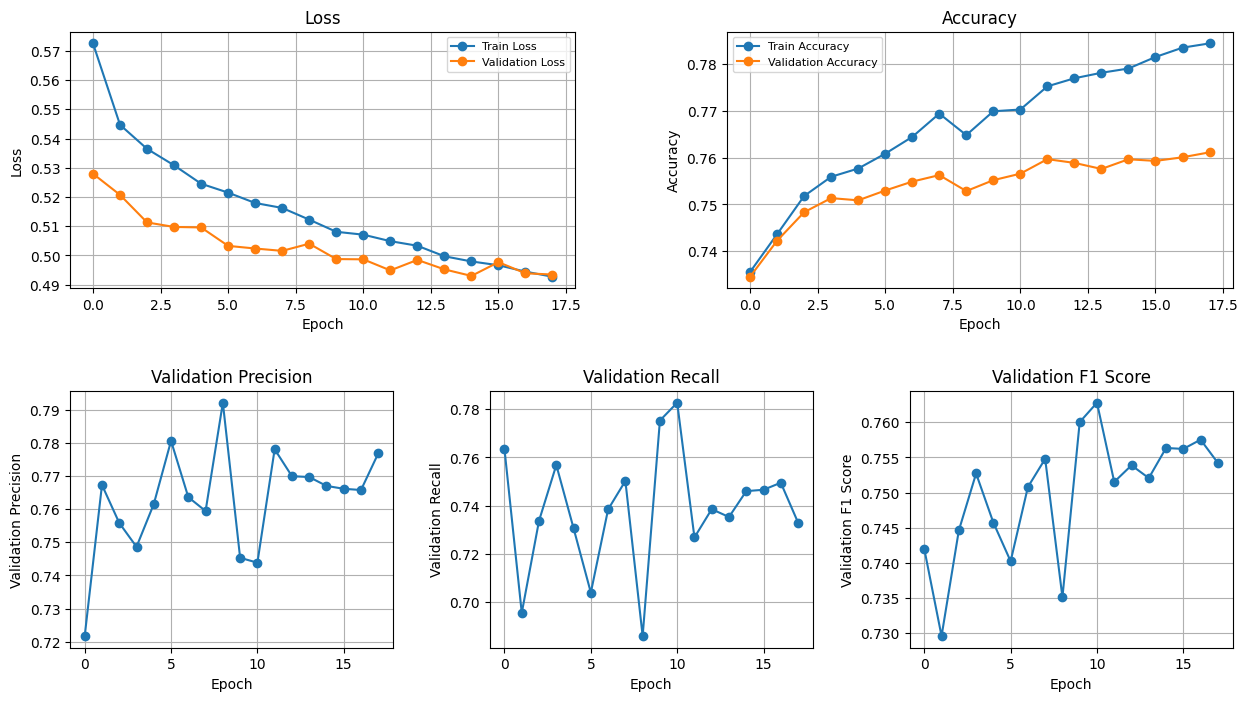

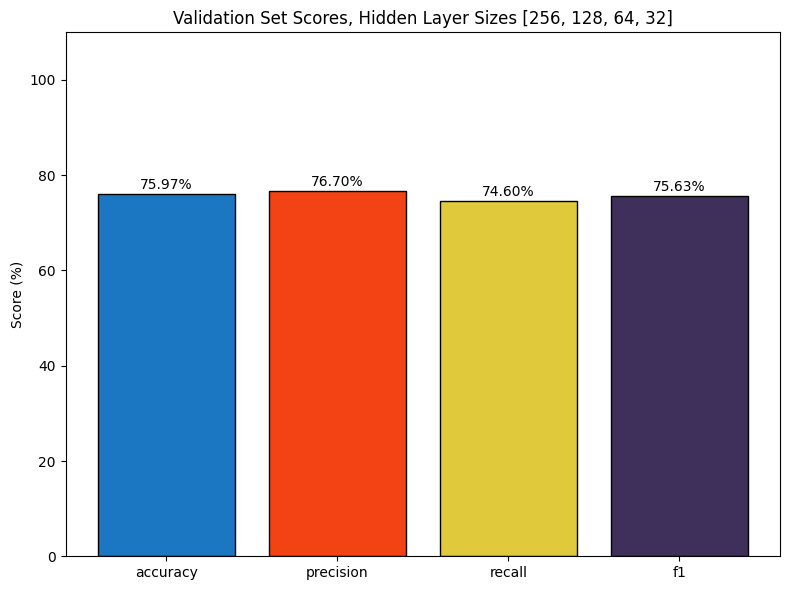

Epoch 1/50 | Train Loss: 0.5654 | Val Loss: 0.5247 | Train Acc: 0.7372 | Val Acc: 0.7351 | Val Precision: 0.7698 | Val Recall: 0.6708 | Val F1: 0.7169
Epoch 2/50 | Train Loss: 0.5386 | Val Loss: 0.5152 | Train Acc: 0.7466 | Val Acc: 0.7441 | Val Precision: 0.7655 | Val Recall: 0.7038 | Val F1: 0.7333
Epoch 3/50 | Train Loss: 0.5281 | Val Loss: 0.5109 | Train Acc: 0.7539 | Val Acc: 0.7481 | Val Precision: 0.7683 | Val Recall: 0.7105 | Val F1: 0.7382
Epoch 4/50 | Train Loss: 0.5214 | Val Loss: 0.5060 | Train Acc: 0.7580 | Val Acc: 0.7500 | Val Precision: 0.7469 | Val Recall: 0.7563 | Val F1: 0.7516
Epoch 5/50 | Train Loss: 0.5170 | Val Loss: 0.5015 | Train Acc: 0.7627 | Val Acc: 0.7545 | Val Precision: 0.7722 | Val Recall: 0.7219 | Val F1: 0.7462
Epoch 6/50 | Train Loss: 0.5104 | Val Loss: 0.4989 | Train Acc: 0.7663 | Val Acc: 0.7545 | Val Precision: 0.7585 | Val Recall: 0.7467 | Val F1: 0.7525
Epoch 7/50 | Train Loss: 0.5063 | Val Loss: 0.4974 | Train Acc: 0.7679 | Val Acc: 0.7572 | Val

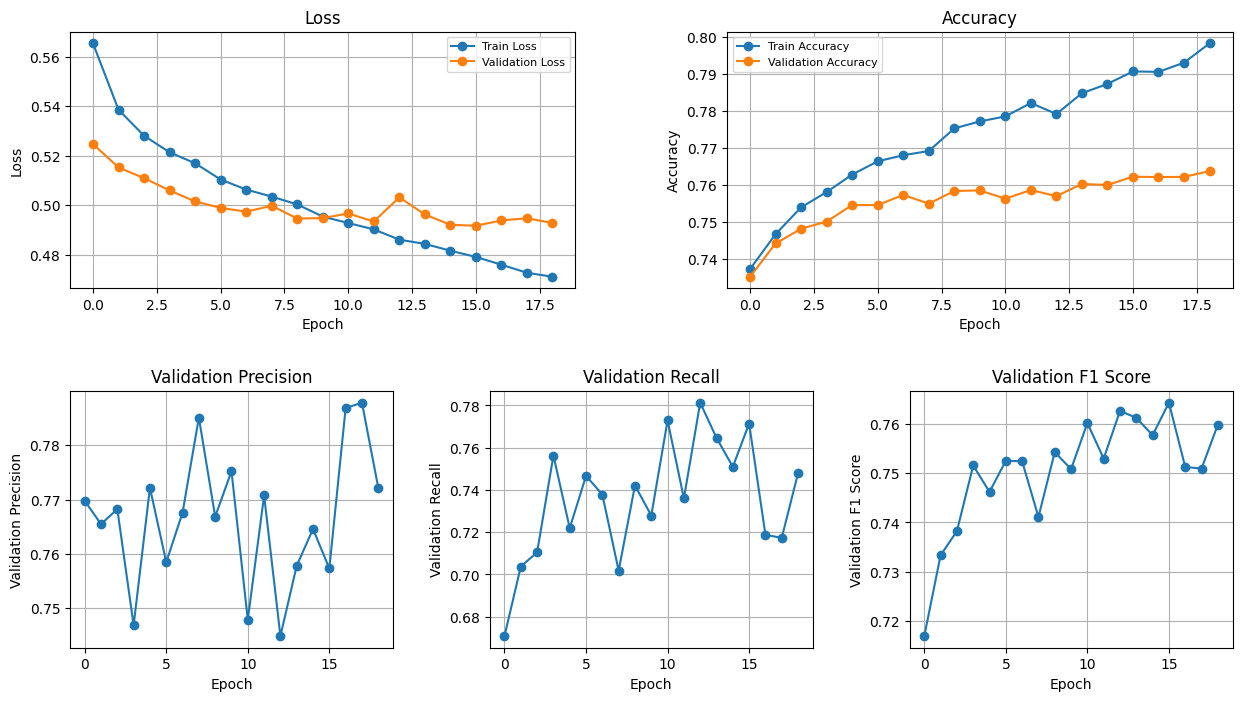

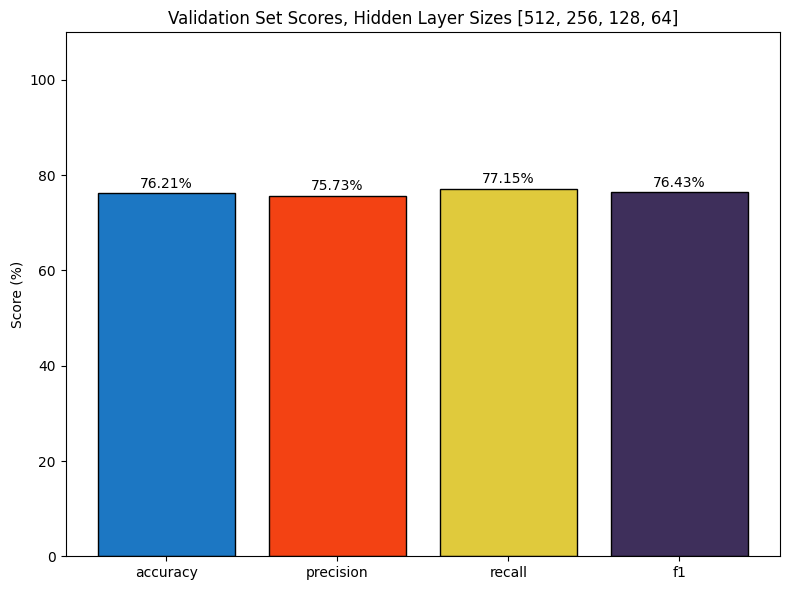

In [280]:
for hd_size in hidden_sizes_list:

    activations = [nn.ReLU] * len(hd_size)
    model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=hd_size, dropout=0.5, D_out=1, activations=activations).to(device)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    results = train_model(
        model, 
        train_loader, 
        val_loader, 
        loss_fn, 
        optimizer, 
        n_epochs=50,
        device=device,
        early=True,
    )

    plot_epochs_scores(results)
    plot_best_scores(results, f'Validation Set Scores, Hidden Layer Sizes {hd_size}')

## GET BEST HIDDEN LAYERS TO WORK WITH

Epoch 1/50 | Train Loss: 0.5726 | Val Loss: 0.5208 | Train Acc: 0.7428 | Val Acc: 0.7411 | Val Precision: 0.7684 | Val Recall: 0.6902 | Val F1: 0.7272
Epoch 2/50 | Train Loss: 0.5392 | Val Loss: 0.5128 | Train Acc: 0.7519 | Val Acc: 0.7477 | Val Precision: 0.7683 | Val Recall: 0.7093 | Val F1: 0.7376
Epoch 3/50 | Train Loss: 0.5306 | Val Loss: 0.5092 | Train Acc: 0.7538 | Val Acc: 0.7504 | Val Precision: 0.7892 | Val Recall: 0.6833 | Val F1: 0.7324
Epoch 4/50 | Train Loss: 0.5233 | Val Loss: 0.5026 | Train Acc: 0.7614 | Val Acc: 0.7542 | Val Precision: 0.7710 | Val Recall: 0.7234 | Val F1: 0.7464
Epoch 5/50 | Train Loss: 0.5195 | Val Loss: 0.5023 | Train Acc: 0.7633 | Val Acc: 0.7552 | Val Precision: 0.7404 | Val Recall: 0.7861 | Val F1: 0.7626
Epoch 6/50 | Train Loss: 0.5157 | Val Loss: 0.4959 | Train Acc: 0.7695 | Val Acc: 0.7597 | Val Precision: 0.7768 | Val Recall: 0.7288 | Val F1: 0.7520
Epoch 7/50 | Train Loss: 0.5108 | Val Loss: 0.4922 | Train Acc: 0.7722 | Val Acc: 0.7601 | Val

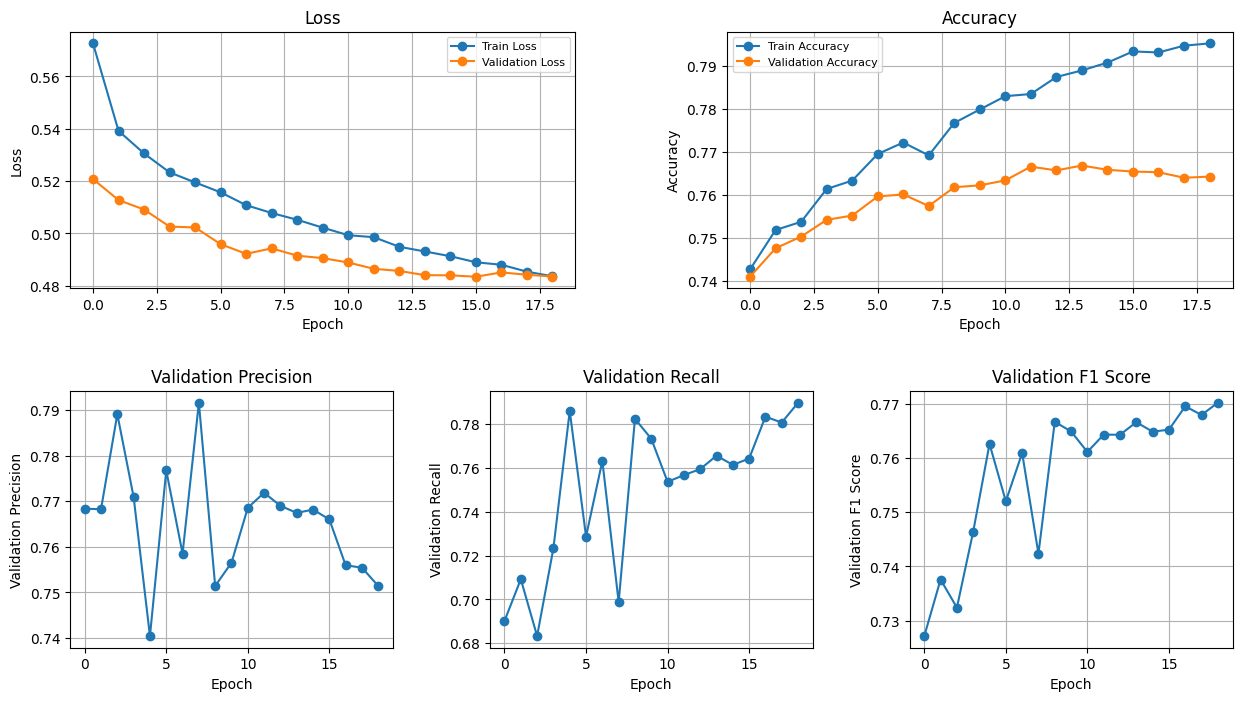

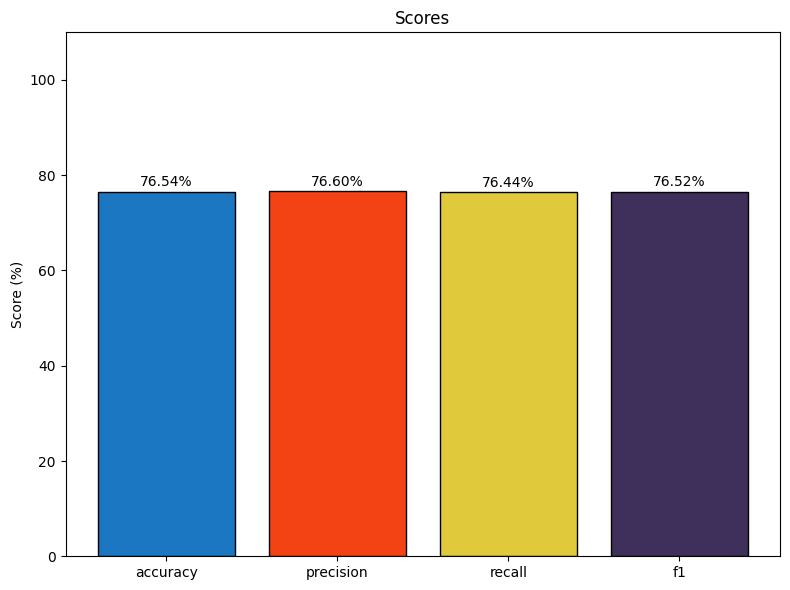

In [261]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[256, 128, 64, 32], dropout=0.5, 
                  D_out=1, activations=[nn.ReLU] * 4, enable_batch_norm=True).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    n_epochs=50,
    device=device,
    early=True
)

plot_epochs_scores(results)
plot_best_scores(results)

Epoch 1/50 | Train Loss: 0.5759 | Val Loss: 0.5218 | Train Acc: 0.7448 | Val Acc: 0.7421 | Val Precision: 0.7354 | Val Recall: 0.7564 | Val F1: 0.7457
Epoch 2/50 | Train Loss: 0.5445 | Val Loss: 0.5118 | Train Acc: 0.7540 | Val Acc: 0.7511 | Val Precision: 0.7596 | Val Recall: 0.7347 | Val F1: 0.7469
Epoch 3/50 | Train Loss: 0.5343 | Val Loss: 0.5061 | Train Acc: 0.7601 | Val Acc: 0.7533 | Val Precision: 0.7685 | Val Recall: 0.7251 | Val F1: 0.7462
Epoch 4/50 | Train Loss: 0.5276 | Val Loss: 0.5012 | Train Acc: 0.7640 | Val Acc: 0.7561 | Val Precision: 0.7569 | Val Recall: 0.7547 | Val F1: 0.7558
Epoch 5/50 | Train Loss: 0.5216 | Val Loss: 0.5001 | Train Acc: 0.7637 | Val Acc: 0.7572 | Val Precision: 0.7824 | Val Recall: 0.7126 | Val F1: 0.7458
Epoch 6/50 | Train Loss: 0.5188 | Val Loss: 0.4950 | Train Acc: 0.7705 | Val Acc: 0.7592 | Val Precision: 0.7608 | Val Recall: 0.7563 | Val F1: 0.7585
Epoch 7/50 | Train Loss: 0.5133 | Val Loss: 0.4975 | Train Acc: 0.7715 | Val Acc: 0.7583 | Val

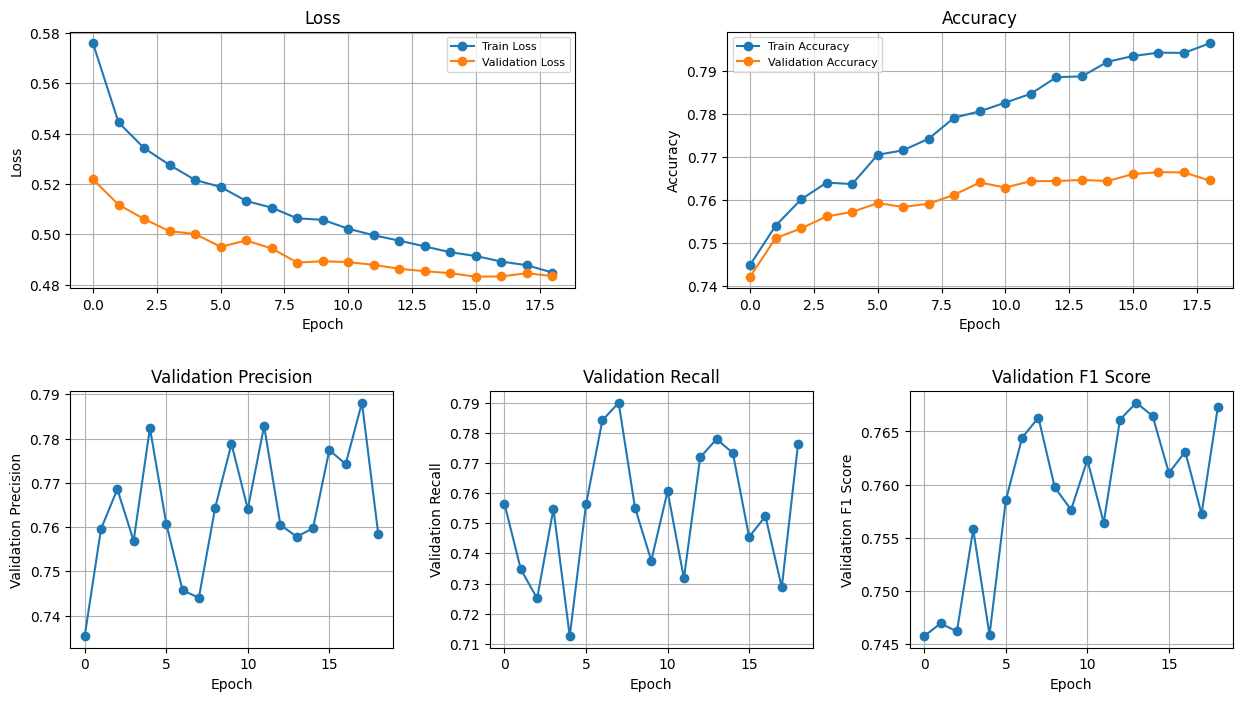

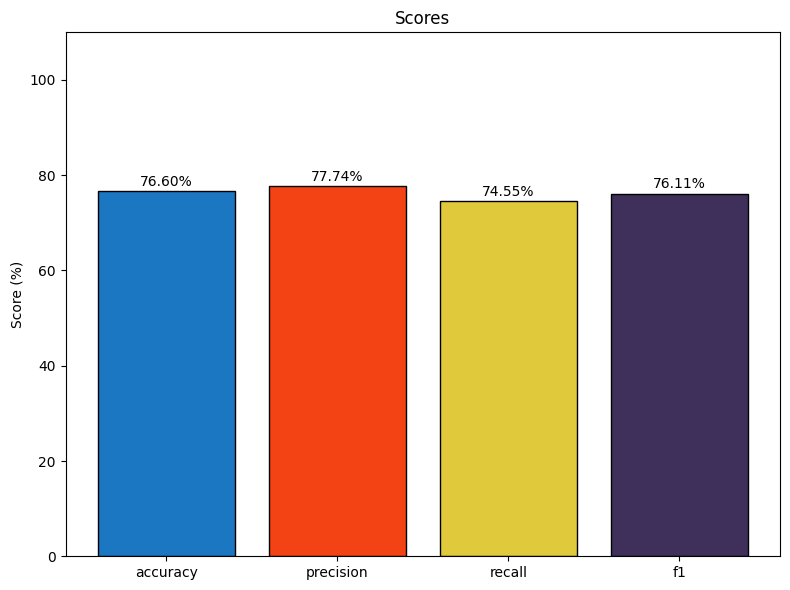

In [277]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[256, 128, 64, 32], dropout=0.5, 
                  D_out=1, activations=[nn.ReLU] * 3 + [nn.Sigmoid], enable_batch_norm=True).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    n_epochs=50,
    device=device,
    early=True
)

plot_epochs_scores(results)
plot_best_scores(results)

Epoch 1/50 | Train Loss: 0.5765 | Val Loss: 0.5298 | Train Acc: 0.7367 | Val Acc: 0.7344 | Val Precision: 0.7074 | Val Recall: 0.7996 | Val F1: 0.7506
Epoch 2/50 | Train Loss: 0.5443 | Val Loss: 0.5173 | Train Acc: 0.7464 | Val Acc: 0.7425 | Val Precision: 0.7124 | Val Recall: 0.8132 | Val F1: 0.7595
Epoch 3/50 | Train Loss: 0.5350 | Val Loss: 0.5070 | Train Acc: 0.7591 | Val Acc: 0.7538 | Val Precision: 0.7544 | Val Recall: 0.7529 | Val F1: 0.7536
Epoch 4/50 | Train Loss: 0.5276 | Val Loss: 0.5025 | Train Acc: 0.7647 | Val Acc: 0.7554 | Val Precision: 0.7630 | Val Recall: 0.7408 | Val F1: 0.7517
Epoch 5/50 | Train Loss: 0.5221 | Val Loss: 0.5043 | Train Acc: 0.7601 | Val Acc: 0.7512 | Val Precision: 0.7995 | Val Recall: 0.6704 | Val F1: 0.7293
Epoch 6/50 | Train Loss: 0.5161 | Val Loss: 0.4971 | Train Acc: 0.7663 | Val Acc: 0.7574 | Val Precision: 0.7897 | Val Recall: 0.7017 | Val F1: 0.7431
Epoch 7/50 | Train Loss: 0.5138 | Val Loss: 0.4933 | Train Acc: 0.7739 | Val Acc: 0.7594 | Val

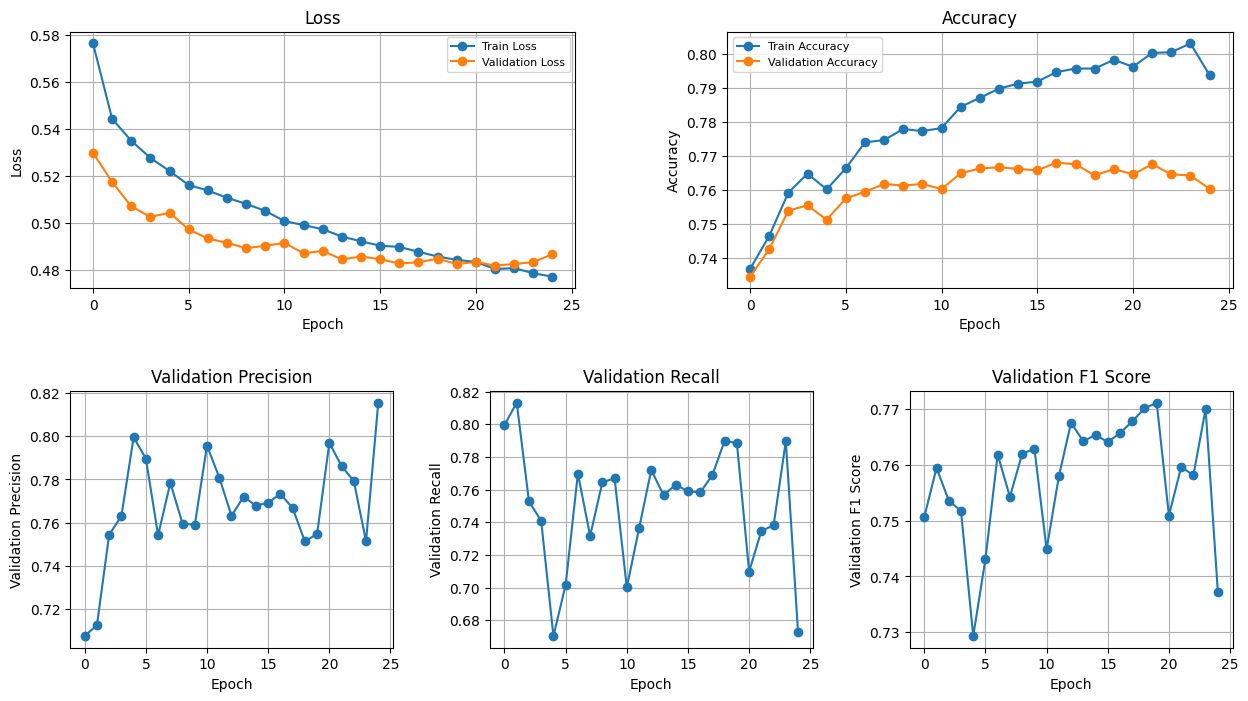

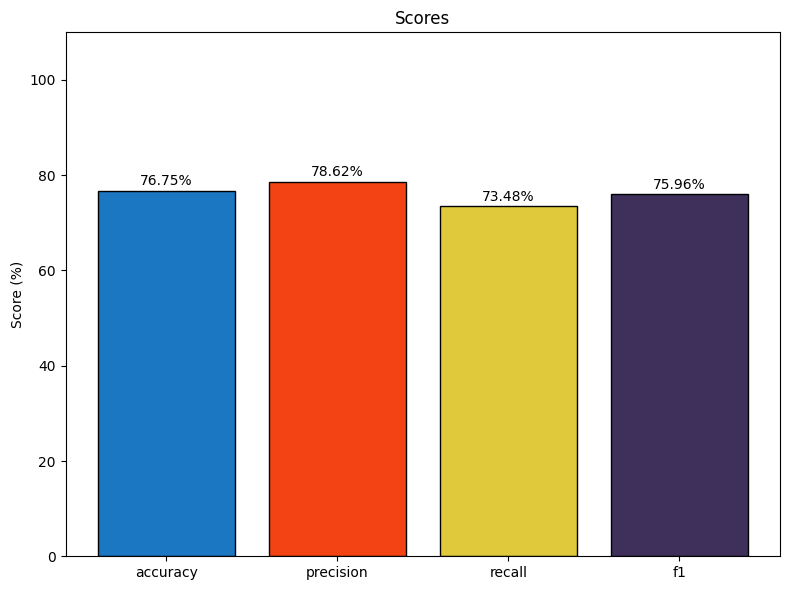

In [278]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[256, 128, 64, 32], dropout=0.5, 
                  D_out=1, activations=[nn.LeakyReLU] * 3 + [nn.Sigmoid], enable_batch_norm=True).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    n_epochs=50,
    device=device,
    early=True
)

plot_epochs_scores(results)
plot_best_scores(results)

In [295]:
def objective(trial):
    hidden_sizes = [256, 128, 64]

    activations = []
    for i in range(len(hidden_sizes)):
        act_fn = trial.suggest_categorical(f'activation_layer_{i}', [nn.ReLU, nn.Tanh, nn.SiLU])
        activations.append(act_fn)

    optimizer_name = trial.suggest_categorical('optimizer', ['AdamW', 'SGD', 'RMSprop'])

    dropout = trial.suggest_float('dropout', 0.1, 0.5)

    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)

    model = NeuralNet(
        D_in=X_train_tensor.shape[1],
        hidden_sizes=hidden_sizes,
        D_out=1,
        activations=activations,
        dropout=dropout,
        enable_batch_norm=True
    ).to(device)

    if optimizer_name == 'AdamW':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)

    loss_fn = nn.BCEWithLogitsLoss()

    train_model(
        model,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        n_epochs=50,
        device=device,
        early=True,
        print_res=1
    )

    val_metrics = evaluate_model(model, val_loader, loss_fn, device=device)

    return 1.0 - val_metrics['Accuracy']

In [296]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best Parameters:")
print(study.best_trial.params)

[I 2025-04-11 21:09:10,435] A new study created in memory with name: no-name-1e2e2654-baaa-4899-b544-b5f539f1252f


Epoch 1/50 | Train Loss: 0.6284 | Val Loss: 0.5591 | Train Acc: 0.7145 | Val Acc: 0.7144 | Val Precision: 0.7534 | Val Recall: 0.6374 | Val F1: 0.6906
Epoch 2/50 | Train Loss: 0.5714 | Val Loss: 0.5398 | Train Acc: 0.7264 | Val Acc: 0.7254 | Val Precision: 0.7593 | Val Recall: 0.6600 | Val F1: 0.7062
Epoch 3/50 | Train Loss: 0.5578 | Val Loss: 0.5325 | Train Acc: 0.7311 | Val Acc: 0.7308 | Val Precision: 0.7570 | Val Recall: 0.6799 | Val F1: 0.7164
Epoch 4/50 | Train Loss: 0.5513 | Val Loss: 0.5310 | Train Acc: 0.7317 | Val Acc: 0.7302 | Val Precision: 0.7682 | Val Recall: 0.6596 | Val F1: 0.7097
Epoch 5/50 | Train Loss: 0.5470 | Val Loss: 0.5260 | Train Acc: 0.7357 | Val Acc: 0.7364 | Val Precision: 0.7536 | Val Recall: 0.7026 | Val F1: 0.7272
Epoch 6/50 | Train Loss: 0.5429 | Val Loss: 0.5243 | Train Acc: 0.7372 | Val Acc: 0.7366 | Val Precision: 0.7560 | Val Recall: 0.6988 | Val F1: 0.7263
Epoch 7/50 | Train Loss: 0.5406 | Val Loss: 0.5247 | Train Acc: 0.7377 | Val Acc: 0.7369 | Val

[I 2025-04-11 21:11:35,174] Trial 0 finished with value: 0.24407963015378809 and parameters: {'activation_layer_0': <class 'torch.nn.modules.activation.Tanh'>, 'activation_layer_1': <class 'torch.nn.modules.activation.ReLU'>, 'activation_layer_2': <class 'torch.nn.modules.activation.ReLU'>, 'optimizer': 'RMSprop', 'dropout': 0.4321158944794363, 'lr': 3.354536609888973e-05}. Best is trial 0 with value: 0.24407963015378809.


Epoch 1/50 | Train Loss: 0.5444 | Val Loss: 0.5279 | Train Acc: 0.7343 | Val Acc: 0.7349 | Val Precision: 0.7702 | Val Recall: 0.6697 | Val F1: 0.7164
Epoch 2/50 | Train Loss: 0.5265 | Val Loss: 0.5159 | Train Acc: 0.7453 | Val Acc: 0.7430 | Val Precision: 0.7306 | Val Recall: 0.7698 | Val F1: 0.7497
Epoch 3/50 | Train Loss: 0.5179 | Val Loss: 0.5130 | Train Acc: 0.7504 | Val Acc: 0.7453 | Val Precision: 0.7342 | Val Recall: 0.7690 | Val F1: 0.7512
Epoch 4/50 | Train Loss: 0.5116 | Val Loss: 0.5071 | Train Acc: 0.7560 | Val Acc: 0.7489 | Val Precision: 0.7382 | Val Recall: 0.7715 | Val F1: 0.7545
Epoch 5/50 | Train Loss: 0.5047 | Val Loss: 0.5043 | Train Acc: 0.7608 | Val Acc: 0.7505 | Val Precision: 0.7384 | Val Recall: 0.7759 | Val F1: 0.7567
Epoch 6/50 | Train Loss: 0.5001 | Val Loss: 0.4978 | Train Acc: 0.7675 | Val Acc: 0.7539 | Val Precision: 0.7697 | Val Recall: 0.7248 | Val F1: 0.7466
Epoch 7/50 | Train Loss: 0.4944 | Val Loss: 0.5025 | Train Acc: 0.7676 | Val Acc: 0.7503 | Val

[I 2025-04-11 21:12:34,764] Trial 1 finished with value: 0.24683932446457213 and parameters: {'activation_layer_0': <class 'torch.nn.modules.activation.Tanh'>, 'activation_layer_1': <class 'torch.nn.modules.activation.Tanh'>, 'activation_layer_2': <class 'torch.nn.modules.activation.ReLU'>, 'optimizer': 'AdamW', 'dropout': 0.21458354353362252, 'lr': 0.0027910347875167883}. Best is trial 0 with value: 0.24407963015378809.


...

Epoch 1/50 | Train Loss: 0.5676 | Val Loss: 0.5209 | Train Acc: 0.7395 | Val Acc: 0.7395 | Val Precision: 0.7514 | Val Recall: 0.7159 | Val F1: 0.7332
Epoch 2/50 | Train Loss: 0.5337 | Val Loss: 0.5135 | Train Acc: 0.7446 | Val Acc: 0.7437 | Val Precision: 0.7668 | Val Recall: 0.7005 | Val F1: 0.7321
Epoch 3/50 | Train Loss: 0.5244 | Val Loss: 0.5094 | Train Acc: 0.7496 | Val Acc: 0.7480 | Val Precision: 0.7341 | Val Recall: 0.7778 | Val F1: 0.7553
Epoch 4/50 | Train Loss: 0.5183 | Val Loss: 0.5039 | Train Acc: 0.7549 | Val Acc: 0.7501 | Val Precision: 0.7479 | Val Recall: 0.7545 | Val F1: 0.7512
Epoch 5/50 | Train Loss: 0.5123 | Val Loss: 0.4994 | Train Acc: 0.7580 | Val Acc: 0.7539 | Val Precision: 0.7509 | Val Recall: 0.7600 | Val F1: 0.7554
Epoch 6/50 | Train Loss: 0.5077 | Val Loss: 0.4989 | Train Acc: 0.7605 | Val Acc: 0.7547 | Val Precision: 0.7391 | Val Recall: 0.7874 | Val F1: 0.7625
Epoch 7/50 | Train Loss: 0.5044 | Val Loss: 0.4955 | Train Acc: 0.7622 | Val Acc: 0.7546 | Val

[I 2025-04-11 21:40:47,976] Trial 16 finished with value: 0.23263987168600808 and parameters: {'activation_layer_0': <class 'torch.nn.modules.activation.SiLU'>, 'activation_layer_1': <class 'torch.nn.modules.activation.Tanh'>, 'activation_layer_2': <class 'torch.nn.modules.activation.SiLU'>, 'optimizer': 'AdamW', 'dropout': 0.34911333935435457, 'lr': 0.00011770861743967037}. Best is trial 12 with value: 0.23080007547881876.


Epoch 1/50 | Train Loss: 0.7034 | Val Loss: 0.6761 | Train Acc: 0.5723 | Val Acc: 0.5744 | Val Precision: 0.6312 | Val Recall: 0.3578 | Val F1: 0.4568
Epoch 2/50 | Train Loss: 0.6826 | Val Loss: 0.6606 | Train Acc: 0.6138 | Val Acc: 0.6154 | Val Precision: 0.6750 | Val Recall: 0.4453 | Val F1: 0.5366
Epoch 3/50 | Train Loss: 0.6692 | Val Loss: 0.6476 | Train Acc: 0.6388 | Val Acc: 0.6410 | Val Precision: 0.6987 | Val Recall: 0.4957 | Val F1: 0.5800
Epoch 4/50 | Train Loss: 0.6569 | Val Loss: 0.6369 | Train Acc: 0.6574 | Val Acc: 0.6611 | Val Precision: 0.7096 | Val Recall: 0.5455 | Val F1: 0.6168
Epoch 5/50 | Train Loss: 0.6453 | Val Loss: 0.6249 | Train Acc: 0.6707 | Val Acc: 0.6731 | Val Precision: 0.7142 | Val Recall: 0.5772 | Val F1: 0.6384
Epoch 6/50 | Train Loss: 0.6351 | Val Loss: 0.6157 | Train Acc: 0.6781 | Val Acc: 0.6793 | Val Precision: 0.7253 | Val Recall: 0.5772 | Val F1: 0.6429
Epoch 7/50 | Train Loss: 0.6262 | Val Loss: 0.6057 | Train Acc: 0.6872 | Val Acc: 0.6886 | Val

[W 2025-04-11 21:41:24,132] Trial 17 failed with parameters: {'activation_layer_0': <class 'torch.nn.modules.activation.SiLU'>, 'activation_layer_1': <class 'torch.nn.modules.activation.ReLU'>, 'activation_layer_2': <class 'torch.nn.modules.activation.SiLU'>, 'optimizer': 'SGD', 'dropout': 0.2964218661146171, 'lr': 0.0003986663099473045} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/angel/Documents/uoa master/AI2/nlp-project-2/myenv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_6141/554363035.py", line 33, in objective
    train_model(
  File "/tmp/ipykernel_6141/1797632281.py", line 19, in train_model
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device=device)
  File "/tmp/ipykernel_6141/2544253920.py", line 5, in train_epoch
    for x_batch, y_batch in dataloader:
  File "/home/angel/Documents/uoa master/AI2/nlp-p

KeyboardInterrupt: 

### Storing the label predictions among with the tweet IDs in a CSV file

In [ ]:
# pd.DataFrame({
#     'ID': df_test['ID'],
#     'Label': y_test_pred
# }).to_csv('submission.csv', index=False)